# Real Estate Pricing Intelligence

--- 

## 🏢 Contexto: a empresa Cascade Urban Analytics

A Cascade Urban Analytics é uma empresa de inteligência imobiliária que atua na região de King County (Seattle). Ela fornece:

valuation de imóveis
insights para incorporadoras
recomendação de investimento para fundos imobiliários
suporte a plataformas de compra/venda

**📉 Problema de fundo**

Nos últimos 18 meses, o mercado ficou mais volátil:

- Preços variando muito entre regiões próximas
- Clientes institucionais exigindo previsões mais confiáveis
- Concorrentes usando modelos mais sofisticados
- A empresa percebeu que seu modelo atual não está capturando a complexidade espacial e estrutural dos preços.

---

<p align="left">
  <img src="cascade_price_intelligence_cover.png" width="800">
</p>

---

🧩 Problemas de negócio 

🔴 Problema 1 — Valuation inconsistente

Situação

**Clientes reclamam que:**

- Imóveis semelhantes recebem preços muito diferentes
- Avaliações não refletem localização corretamente
- Erros altos em imóveis premium

**Impacto:**

- Perda de confiança
- Churn de clientes institucionais
- Decisões ruins de investimento

**Pergunta de negócio**

“Como podemos prever o preço de um imóvel com alta precisão considerando localização, características e qualidade?”

---

---

🔵 Problema 2 — **Identificação de oportunidades de investimento**

**Situação**

Fundos parceiros querem saber:

- Onde comprar imóveis subvalorizados    
- Quais regiões têm maior potencial de valorização
    

Hoje a empresa não consegue responder isso de forma quantitativa.

**Impacto**

- Perda de contratos com fundos imobiliários    
- Decisões baseadas em intuição (alto risco)
    

**Pergunta de negócio**

> “Quais imóveis estão sendo vendidos abaixo do valor esperado?”

---

---

🟢 Problema 3 — **Compreensão dos drivers de preço**

**Situação**

**Executivos e clientes perguntam:**

- O que realmente impacta o preço?    
- Vale mais investir em reforma ou localização?
- Quantos banheiros realmente agregam valor?
    

E hoje a empresa não tem respostas claras.

**Impacto**

- Dificuldade em justificar decisões
- Perda de credibilidade analítica
    

**Pergunta de negócio**

> Quais variáveis mais influenciam o preço e como?

---

# Feature Menu

* [1.0 Data Understanding & Cleaning](#10-Data-Understanding-&-Cleaning)
* [2.0 Feature Engineering](#20-Feature-Engineering)
* [3.0 Exploratory Data Analysis (EDA)](#30-Exploratory-Data-Analysis-(EDA))
* [4.0 Modelagem Preditiva](#40-Modelagem-Preditiva)
* [5.0 Validacao e Metricas](#5.0-Validacao-e-Metricas)
* [6.0 Interpretabilidade](#6.0-Interpretabilidade)
* [7.0 Geracao de Insights](#7.0-Geracao-de-Insights)
 

# 1.0 Data Understanding & Cleaning

## 1.1 Baixando e Carregando os Dados

In [1]:
import importlib    # Importa o módulo 'importlib', que permite importar bibliotecas dinamicamente em tempo de execução
import subprocess   # Importa o módulo 'subprocess' para executar comandos externos, como instalar pacotes via pip
import sys          # Importa o módulo 'sys' para acessar o interpretador Python atual e seu executável


# Dicionário contendo os pacotes que devem ser verificados e instalados, se necessário.
# Estrutura: {nome_import: nome_instalacao_pip}
required_packages = {
    'sklearn': 'scikit-learn',     # Alias crítico: módulo é 'sklearn', mas distribuição no pip é 'scikit-learn'
    'scipy': 'scipy',              # Nome consistente entre importação e instalação
    'pandas': 'pandas',            # DataFrames e manipulação de dados estruturados
    'numpy': 'numpy',              # Base para computação numérica vetorizada
    'matplotlib': 'matplotlib',    # Biblioteca base para visualização (baixo nível)
    'seaborn': 'seaborn',          # Abstração estatística sobre matplotlib
    'missingno': 'missingno',      # Visualização de padrões de dados ausentes (EDA)
    'plotly': 'plotly',            # Visualização interativa (frontend-ready)
    'statsmodels': 'statsmodels',  # Modelagem estatística (inferência, regressões)
    'statstests': 'statstests',    # Testes estatísticos adicionais (menos comum, cuidado com compatibilidade)
    'missingno': 'missingno',      # Biblioteca para visualização de dados ausentes 
    'datetime': 'datetime'         # Módulo datetime para trabalhar com datas e horários
}
# Função responsável por verificar se o pacote está disponível no ambiente Python
def check_and_install(package_name, install_name):
    try:
        importlib.import_module(package_name)  # Tentativa dinâmica de importação (evita import estático)
        print(f"✅ Biblioteca '{package_name}' já está instalada.")  # Feedback positivo para logging
    except ImportError:  # Captura falha de importação → pacote ausente no ambiente
        print(f"⚠️ Biblioteca '{package_name}' não encontrada. Instalando '{install_name}'...")
        
        # Executa comando de instalação via subprocess:
        # sys.executable garante uso do mesmo interpretador Python ativo (evita conflitos de ambiente)
        # "-m pip install" é mais seguro que chamar pip diretamente (compatibilidade cross-env)
        subprocess.check_call([
            sys.executable,        # Caminho do Python atual
            "-m", "pip",           # Execução do módulo pip
            "install", install_name  # Nome do pacote no repositório PyPI
        ])
        
        print(f"✅ Biblioteca '{install_name}' instalada com sucesso.")  # Confirmação pós-instalação

# Iteração sobre o dicionário de dependências
for package, install_name in required_packages.items():
    check_and_install(package, install_name)  # Execução sequencial (sem paralelismo)

✅ Biblioteca 'sklearn' já está instalada.
✅ Biblioteca 'scipy' já está instalada.
✅ Biblioteca 'pandas' já está instalada.
✅ Biblioteca 'numpy' já está instalada.
✅ Biblioteca 'matplotlib' já está instalada.
✅ Biblioteca 'seaborn' já está instalada.
✅ Biblioteca 'missingno' já está instalada.
✅ Biblioteca 'plotly' já está instalada.
✅ Biblioteca 'statsmodels' já está instalada.
✅ Biblioteca 'statstests' já está instalada.
✅ Biblioteca 'datetime' já está instalada.


In [2]:
import pandas as pd                                 # manipulação de dados em formato de dataframe
import numpy as np                                  # operações matemáticas
import seaborn as sns                               # visualização gráfica
import matplotlib.pyplot as plt                     # visualização gráfica
import plotly.graph_objects as go                   # gráficos 3D
from scipy.stats import pearsonr                    # correlações de Pearson
import statsmodels.api as sm                        # estimação de modelos
from statsmodels.iolib.summary2 import summary_col  # comparação entre modelos
from sklearn.preprocessing import LabelEncoder      # transformação de dados
from statstests.process import stepwise             # procedimento Stepwise
from statstests.tests import shapiro_francia        # teste de Shapiro-Francia
from scipy.stats import boxcox                      # transformação de Box-Cox
from scipy.stats import norm                        # para plotagem da curva normal
from scipy import stats                             # utilizado na definição da função 'breusch_pagan_test'
import missingno as msno                            # Biblioteca para visualização de dados ausentes
from sklearn.linear_model import LinearRegression   # Modelo de Regressão 
from sklearn.model_selection import train_test_split
from datetime import datetime # Importa o módulo datetime para trabalhar com datas e horários

In [3]:
# Versões dos pacotes usados neste jupyter notebook
%reload_ext watermark
%watermark -a "Ricardo de Souza Silva" 

Author: Ricardo de Souza Silva



## 1.2 Carregando os Dados

In [4]:
# Lista para identificar os valores ausentes
lista_labels_valores_ausentes = ["n/a,", "na", "undefined"]

In [5]:
dataset = pd.read_csv('data/house_prices.csv', na_values= lista_labels_valores_ausentes)

In [6]:
dataset.head()

,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,7129300520,20141013T000000,221900.0,3,1.00,1180,5650,1.0,0,0,...,7,1180,0,1955,0,98178,47.5112,-122.257,1340,5650
1,6414100192,20141209T000000,538000.0,3,2.25,2570,7242,2.0,0,0,...,7,2170,400,1951,1991,98125,47.7210,-122.319,1690,7639
2,5631500400,20150225T000000,180000.0,2,1.00,770,10000,1.0,0,0,...,6,770,0,1933,0,98028,47.7379,-122.233,2720,8062
3,2487200875,20141209T000000,604000.0,4,3.00,1960,5000,1.0,0,0,...,7,1050,910,1965,0,98136,47.5208,-122.393,1360,5000
4,1954400510,20150218T000000,510000.0,3,2.00,1680,8080,1.0,0,0,...,8,1680,0,1987,0,98074,47.6168,-122.045,1800,7503


In [7]:
dataset.shape

(21613, 21)

In [8]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21613 entries, 0 to 21612
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   id             21613 non-null  int64  
 1   date           21613 non-null  object 
 2   price          21613 non-null  float64
 3   bedrooms       21613 non-null  int64  
 4   bathrooms      21613 non-null  float64
 5   sqft_living    21613 non-null  int64  
 6   sqft_lot       21613 non-null  int64  
 7   floors         21613 non-null  float64
 8   waterfront     21613 non-null  int64  
 9   view           21613 non-null  int64  
 10  condition      21613 non-null  int64  
 11  grade          21613 non-null  int64  
 12  sqft_above     21613 non-null  int64  
 13  sqft_basement  21613 non-null  int64  
 14  yr_built       21613 non-null  int64  
 15  yr_renovated   21613 non-null  int64  
 16  zipcode        21613 non-null  int64  
 17  lat            21613 non-null  float64
 18  long  

## 1.3 Renomeação e Adequação das Colunas (Variáveis)

---

Visando aprimorar a legibilidade e a interpretabilidade do dataset, foi realizada a padronização da nomenclatura das variáveis do inglês para o português.

Essa decisão facilita o entendimento semântico dos atributos e tornar a análise mais acessível para usuários de língua portuguesa. 

---

In [9]:
renomeando = {
    "price": "preco_venda",                 # variável alvo (target)
    "bedrooms": "num_quartos",              # variável de contagem
    "bathrooms": "num_banheiros",           # pode conter valores fracionados (ex: 1.5)
    "sqft_living": "area_util_pes2",        # área interna habitável (principal feature preditiva)
    "sqft_lot": "area_terreno_pes2",        # área total do terreno
    "floors": "num_andares",                # número de níveis da casa
    "waterfront": "possui_vista_agua",      # variável binária (0 = não, 1 = sim)
    "view": "pontuacao_vista",              # variável ordinal (0 a 4)
    "condition": "pontuacao_condicao",      # estado geral do imóvel (1 a 5)
    "grade": "classificacao_construcao",    # qualidade da construção/design (1 a 13)
    "sqft_above": "area_acima_solo_pes2",   # área acima do nível do solo
    "sqft_basement": "area_porao_pes2",     # área do porão
    "yr_built": "ano_construcao",           # ano de construção
    "yr_renovated": "ano_reforma",          # 0 indica que nunca foi reformado (atenção para feature engineering)
    "zipcode": "codigo_postal",             # variável categórica (não tratar como numérica em modelos)
    "sqft_living15": "area_media_vizinhos_pes2",        # média da área útil das casas vizinhas (contexto regional)
    "sqft_lot15": "area_terreno_media_vizinhos_pes2"    # média da área de terreno da vizinhança
}
# aplica a renomeação das colunas no dataset
dataset = dataset.rename(columns=renomeando)

In [10]:
dataset.drop(labels=['id', 'date', 'lat', 'long'], axis=1, inplace=True)

In [11]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21613 entries, 0 to 21612
Data columns (total 17 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   preco_venda                       21613 non-null  float64
 1   num_quartos                       21613 non-null  int64  
 2   num_banheiros                     21613 non-null  float64
 3   area_util_pes2                    21613 non-null  int64  
 4   area_terreno_pes2                 21613 non-null  int64  
 5   num_andares                       21613 non-null  float64
 6   possui_vista_agua                 21613 non-null  int64  
 7   pontuacao_vista                   21613 non-null  int64  
 8   pontuacao_condicao                21613 non-null  int64  
 9   classificacao_construcao          21613 non-null  int64  
 10  area_acima_solo_pes2              21613 non-null  int64  
 11  area_porao_pes2                   21613 non-null  int64  
 12  ano_

In [12]:
dataset.sample(10)

,preco_venda,num_quartos,num_banheiros,area_util_pes2,area_terreno_pes2,num_andares,possui_vista_agua,pontuacao_vista,pontuacao_condicao,classificacao_construcao,area_acima_solo_pes2,area_porao_pes2,ano_construcao,ano_reforma,codigo_postal,area_media_vizinhos_pes2,area_terreno_media_vizinhos_pes2
1342,780000.0,4,3.00,2440,3600,1.5,0,0,5,8,1480,960,1929,0,98103,1770,4000
9487,2375000.0,4,2.50,3220,20251,1.0,0,0,3,10,3220,0,1969,0,98006,4200,22114
13300,328000.0,4,1.00,1360,8136,1.0,0,0,3,7,1360,0,1948,0,98133,1570,8132
16507,225000.0,2,1.00,1030,9192,1.0,0,0,4,6,1030,0,1959,0,98058,1030,9190
7636,190000.0,1,0.75,780,77603,1.0,0,0,1,5,780,0,1945,0,98058,1750,30847
14343,362500.0,4,1.75,1450,8450,1.0,0,0,3,7,1450,0,1960,0,98027,1540,8450
18540,475000.0,2,2.00,1540,54450,2.0,0,0,3,7,1540,0,1983,0,98053,2280,29918
18020,315000.0,3,2.50,1600,7982,2.0,0,0,3,8,1600,0,1993,0,98001,1890,9830
6494,405000.0,2,1.00,720,4323,1.0,0,0,3,6,720,0,1942,0,98199,1460,3300
2174,638000.0,3,1.00,1830,4400,1.5,0,0,4,8,1720,110,1930,0,98122,1650,4400


## 1.4 Verificação Valores Ausentes

---

Aqui utilizei a função `msno.matrix(dataset)` que tem como objetivo visualizar a distribuição dos valores ausentes no conjunto de dados de forma estruturada e intuitiva. Essa visualização permite identificar rapidamente a presença de dados faltantes, sua concentração em determinadas variáveis e possíveis padrões de ausência ao longo das observações.

Ao analisar a matriz, é possível verificar se os valores ausentes ocorrem de maneira aleatória ou se seguem algum padrão específico, o que é fundamental para orientar a estratégia de tratamento dos dados. Além disso, a visualização auxilia na identificação de colunas com alta proporção de valores nulos, que podem comprometer a qualidade da análise ou do modelo.

Em síntese, uma abordagem como essa contribui para uma avaliação mais robusta da qualidade dos dados, sendo uma etapa essencial no processo de preparação e análise de dados.


---

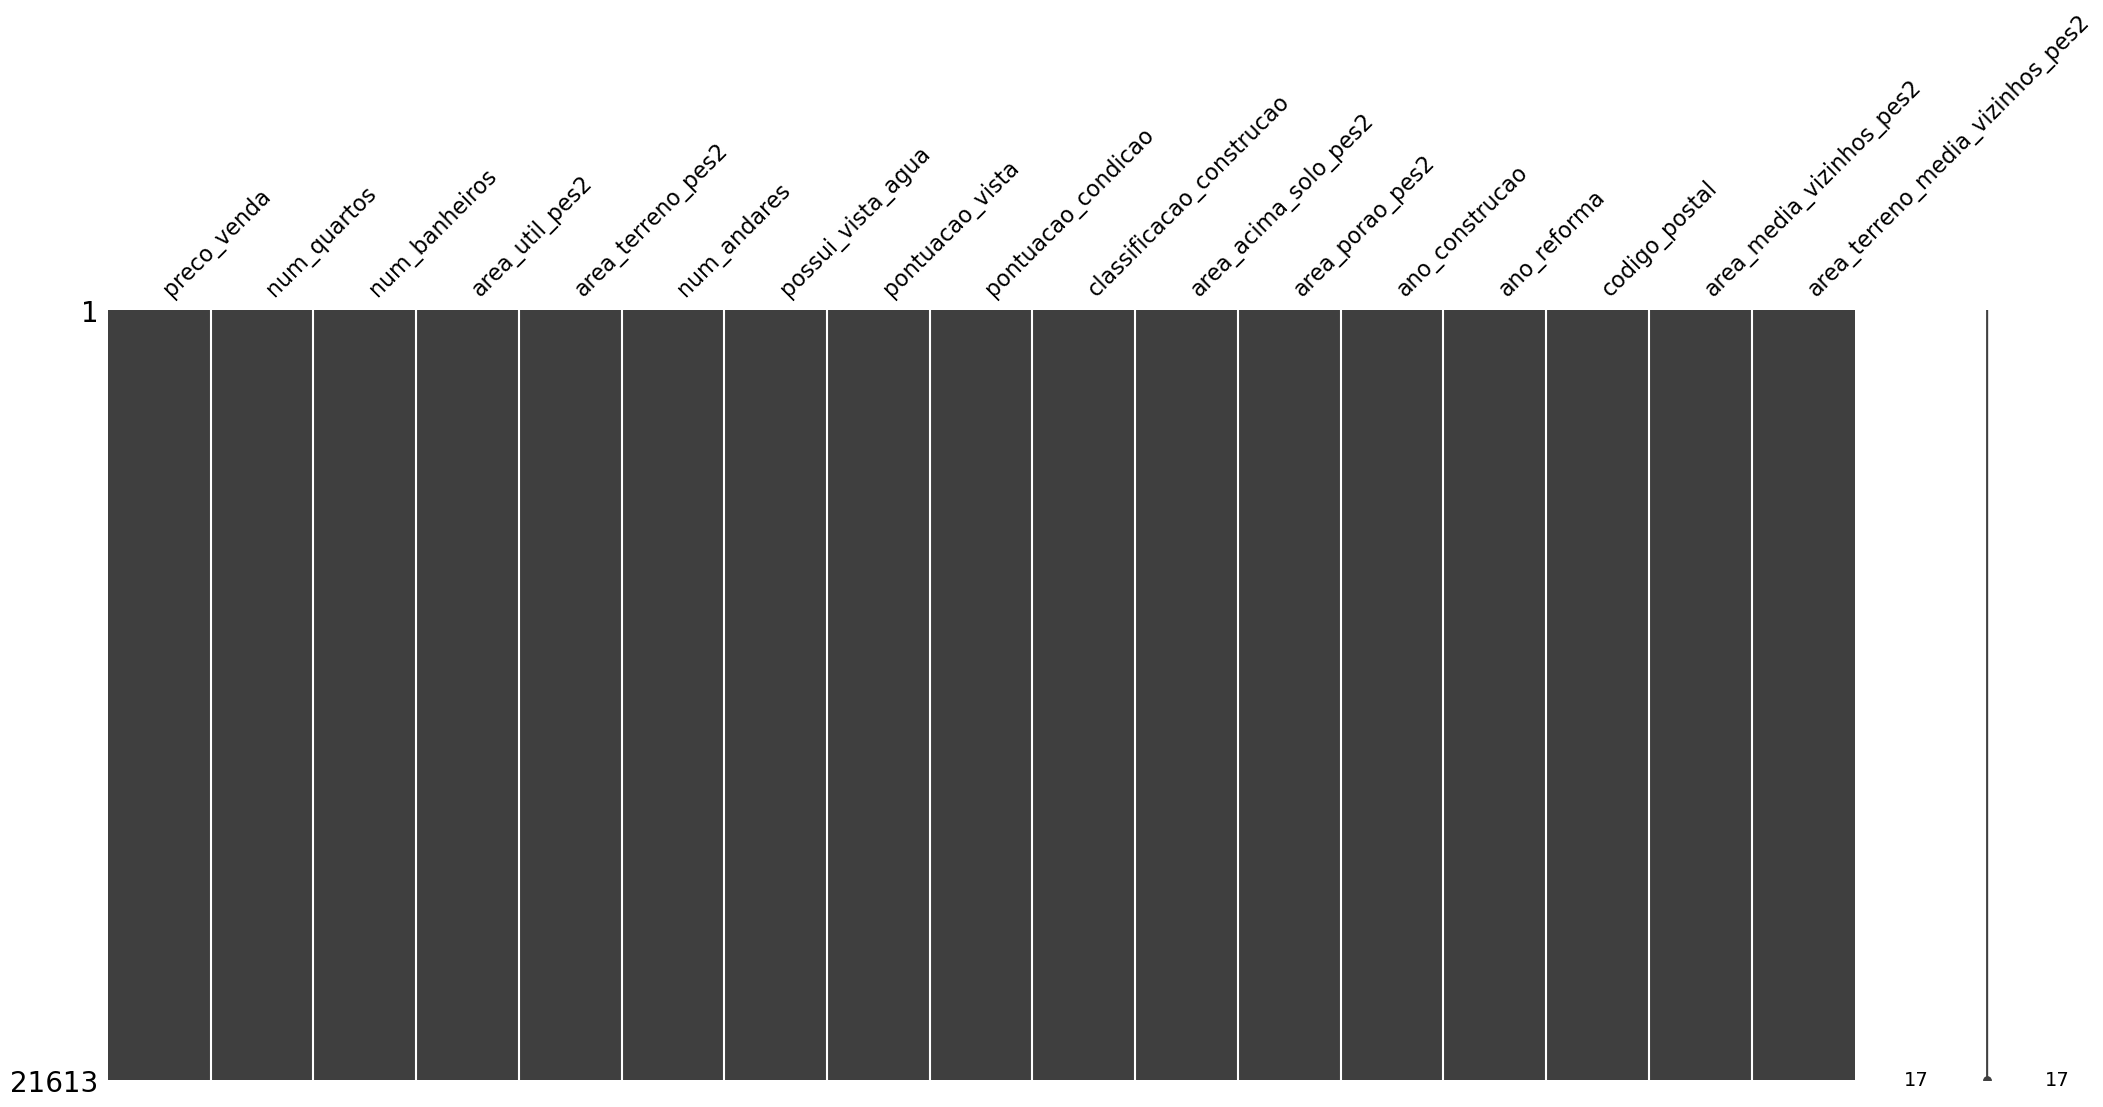

In [13]:
# Matriz de valores ausentes
msno.matrix(dataset)     # Gera uma visualização da matriz de dados ausentes do DataFrame 'dataset'
plt.show()               # Exibe a visualização gerada

# 2.0 Feature Engineering

## 2.1 Tratamento de Variáveis

### 2.1.1 Tratando as Variáveis Temporais (ano_construcao, ano_reforma )

In [14]:
# Calcula a frequência de cada valor presente na coluna 'ano_construcao'
# (ou seja, quantas vezes cada ano de construção aparece no dataset)
dataset['ano_construcao'].value_counts().sort_index()
# Ordena o resultado pelo índice (anos) em ordem crescente,
# permitindo uma análise cronológica da distribuição dos dados

ano_construcao
1900     87
1901     29
1902     27
1903     46
1904     45
       ... 
2011    130
2012    170
2013    201
2014    559
2015     38
Name: count, Length: 116, dtype: int64

In [15]:
# Calcula a frequência de cada valor presente na coluna 'ano_reforma'
# (ou seja, quantas vezes cada ano de construção aparece no dataset)
dataset['ano_reforma'].value_counts().sort_index()
# Ordena o resultado pelo índice (anos) em ordem crescente,
# permitindo uma análise cronológica da distribuição dos dados

ano_reforma
0       20699
1934        1
1940        2
1944        1
1945        3
        ...  
2011       13
2012       11
2013       37
2014       91
2015       16
Name: count, Length: 70, dtype: int64

In [16]:
# Calcula e exibe o percentual de registros em que 'ano_reforma' é igual a 0
# A expressão (dataset['ano_reforma'] == 0) gera uma série booleana (True/False),
# o método .sum() contabiliza os True (equivalentes a 1),
# dividimos pelo total de registros (dataset.shape[0]) e multiplicamos por 100 para obter o percentual,
# e round(..., 2) arredonda o resultado para duas casas decimais
print(f'Percentual de dados com o valor zero em ano da reforma: {round((dataset["ano_reforma"] == 0).sum() / dataset.shape[0] * 100, 3)}')

# Calcula e exibe o percentual de registros em que 'ano_construcao' é igual a 0
# Segue a mesma lógica: contagem de valores iguais a zero sobre o total de registros,
# permitindo avaliar possíveis inconsistências ou ausência de informação nessa variável
print(f'Percentual de dados com o valor zero em ano da construção: {round((dataset["ano_construcao"] == 0).sum() / dataset.shape[0] * 100, 3)}')

Percentual de dados com o valor zero em ano da reforma: 95.771
Percentual de dados com o valor zero em ano da construção: 0.0


In [17]:
# Obtém o ano atual do sistema (ex: 2026), utilizado como referência temporal
# para o cálculo de variáveis derivadas relacionadas ao tempo
ano_atual = datetime.now().year

# Converte a coluna 'ano_construcao' para o tipo datetime
# O parâmetro format='%Y' indica que os valores representam apenas o ano (ex: 1995),
# garantindo consistência no tipo de dado e permitindo o uso do accessor .dt
dataset['ano_construcao'] = pd.to_datetime(dataset['ano_construcao'], format='%Y')

# Cria a variável derivada 'idade_imovel' a partir da diferença entre o ano atual
# e o ano de construção do imóvel
# A operação é vetorizada e utiliza .dt.year para extrair o ano da coluna datetime
# Essa variável tende a ser mais informativa para análise e modelagem do que o ano absoluto
dataset['idade_imovel'] = ano_atual - dataset['ano_construcao'].dt.year

# Remove as colunas 'ano_construcao' e 'ano_reforma' do dataset
# - 'ano_construcao' é descartada por redundância após a criação de 'idade_imovel'
# - 'ano_reforma' é removida devido à alta concentração de valores nulos ou iguais a zero,
#   o que reduz seu poder explicativo e pode introduzir ruído na análise/modelo
dataset.drop(labels=['ano_construcao', 'ano_reforma'], axis=1, inplace=True)

---

**Justificativa para remoção das variáveis**

A variável **`ano_construcao`** foi removida após a criação da variável derivada **`idade_imovel`** (ou *anos de construção*), calculada a partir da diferença entre o ano atual e o ano de construção. Essa transformação permite representar o tempo de forma mais diretamente interpretável e alinhada com o comportamento esperado em modelos preditivos, uma vez que a idade do imóvel tende a capturar melhor o efeito temporal do que o ano absoluto. Além disso, evita-se redundância e possível multicolinearidade entre variáveis altamente correlacionadas.

Já a variável **`ano_reforma`** foi removida devido à alta concentração de valores iguais a zero, indicando ausência de reforma na maior parte dos registros. Essa predominância reduz significativamente o poder informativo da variável, além de dificultar a extração de padrões relevantes. Dessa forma, sua manutenção poderia introduzir ruído no modelo sem contribuir de maneira efetiva para a capacidade explicativa.

---

### 2.1.2 Tratando a Variável (num_banheiros)

In [18]:
dataset['num_banheiros'].value_counts().sort_index()

num_banheiros
0.00      10
0.50       4
0.75      72
1.00    3852
1.25       9
1.50    1446
1.75    3048
2.00    1930
2.25    2047
2.50    5380
2.75    1185
3.00     753
3.25     589
3.50     731
3.75     155
4.00     136
4.25      79
4.50     100
4.75      23
5.00      21
5.25      13
5.50      10
5.75       4
6.00       6
6.25       2
6.50       2
6.75       2
7.50       1
7.75       1
8.00       2
Name: count, dtype: int64

---

#### 🧠 Entendimento dos valores fracionados em `num_banheiros`

Pelo que verifiquei nesse dataset o número de banheiros não é tratado apenas como uma contagem inteira, mas sim como uma **medida ponderada da infraestrutura disponível no imóvel**.

Isso acontece porque nem todos os banheiros possuem o mesmo nível de funcionalidade. Um banheiro completo (com vaso sanitário, pia e chuveiro ou banheira) oferece mais utilidade e conforto do que um lavabo (apenas vaso e pia), por exemplo.

Dessa forma, entendi que esse dataset adota uma convenção onde:

* **banheiros completos** são contabilizados como `1.0`
* **lavabos (meio banheiro)** são contabilizados como `0.5`
* **instalações parciais adicionais** (como um espaço com chuveiro, mas sem todos os componentes) podem contribuir com valores intermediários como `0.25`

Como isso, vou adotar a seguinte estratégia, total de banheiros passa a ser representado como uma variável contínua, podendo assumir valores como:

* `1.0` → um banheiro completo
* `1.5` → um banheiro completo + um lavabo
* `2.75` → dois banheiros completos + combinações parciais adicionais

---

🎯 Por que isso é importante para análise de dados

Essa representação permite capturar melhor o **nível real de conforto e funcionalidade do imóvel**, ao invés de simplesmente contar unidades físicas.

Do ponto de vista analítico:

* dois imóveis com “2 banheiros” podem ser muito diferentes se um deles tiver um lavabo adicional
* o impacto no preço não é uniforme entre componentes completos e parciais
* a variável carrega **informação de qualidade, não apenas quantidade**

---

📌 Conclusão

Portanto, os valores fracionados em `num_banheiros` não são erros ou inconsistências, mas sim uma forma padronizada de representar a composição dos banheiros de um imóvel de maneira mais precisa.

Essa abordagem torna a variável mais informativa e mais adequada para modelagem preditiva, pois reflete melhor a realidade do mercado imobiliário.

---



In [19]:
# cria variáveis derivadas a partir do número total de banheiros

# extrai a parte inteira → representa a quantidade de banheiros completos
# OBS: np.int está depreciado → usar int() ou np.floor para maior segurança
dataset["banheiro_completo"] = dataset["num_banheiros"].astype(int)

# calcula a parte fracionária → representa banheiros complementares (lavabos ou parciais)
dataset["banheiro_complementar"] = dataset["num_banheiros"] - dataset["banheiro_completo"]

# cria variável binária: 1 se existe qualquer banheiro complementar, 0 caso contrário
dataset["banheiro_complementar"] = (dataset["banheiro_complementar"] > 0).astype(int)

# remove a variável original de banheiros após decomposição
# justificativa:
# - a informação foi preservada e melhor representada nas variáveis derivadas
# - evita redundância e possível multicolinearidade no modelo
dataset.drop(labels=['num_banheiros'], axis=1, inplace=True)

In [20]:
dataset.sample(5)

,preco_venda,num_quartos,area_util_pes2,area_terreno_pes2,num_andares,possui_vista_agua,pontuacao_vista,pontuacao_condicao,classificacao_construcao,area_acima_solo_pes2,area_porao_pes2,codigo_postal,area_media_vizinhos_pes2,area_terreno_media_vizinhos_pes2,idade_imovel,banheiro_completo,banheiro_complementar
7268,195000.0,3,1190,14777,1.0,0,0,4,7,1190,0,98023,2240,8325,61,1,1
10121,749950.0,4,2620,8312,2.0,0,0,3,9,2620,0,98074,2260,8515,36,2,1
20841,1258000.0,4,4360,6000,2.0,0,3,3,11,3400,960,98027,4310,6000,19,3,1
4171,245000.0,4,2010,7561,1.5,0,0,4,7,1890,120,98002,1420,6564,105,1,1
9161,748000.0,4,3220,8379,2.0,0,0,3,10,3220,0,98034,2720,7635,22,2,1


### 2.1.3 Tratando a Variável (num_andares)

In [21]:
dataset[['num_andares']].value_counts().sort_index()

num_andares
1.0            10680
1.5             1910
2.0             8241
2.5              161
3.0              613
3.5                8
Name: count, dtype: int64

#### 🧠 Tratamento da variável `num_andares`

A variável `num_andares` possui valores fracionados porque o padrão arquitetônico americano difere do brasileiro.

Nos EUA, é comum que imóveis tenham:

* sótãos habitáveis (*attics*);
* mezaninos;
* níveis superiores parcialmente aproveitados.

Por isso, o mercado imobiliário americano classifica imóveis com “meios andares”, algo pouco comum na padronização brasileira, onde normalmente os imóveis são descritos apenas por andares completos.

Exemplos:

* `1.0` → um andar completo
* `1.5` → um andar + espaço parcial habitável
* `2.0` → dois andares completos
* `2.5` → dois andares + nível parcial

Esses níveis parciais geralmente possuem:

* menor área útil;
* pé-direito reduzido;
* função complementar (quarto, escritório, depósito etc.).

---

#### 📊 Impacto analítico

Tratar essa variável como contínua pode induzir interpretações incorretas, assumindo que `1.5` representa exatamente o meio termo entre `1` e `2`, quando na prática existe uma diferença estrutural e funcional entre os tipos de construção.

---

#### 🔧 Estratégia de Feature Engineering

Para separar melhor esses efeitos, a variável foi decomposta em:

* **`numero_andares`** → parte inteira
  Representa os andares completos do imóvel.

* **`andar_apoio`** → presença de nível parcial
  Variável binária:

  * `0` → não possui andar parcial
  * `1` → possui andar parcial

---

#### 🎯 Objetivo da abordagem

Separar:

* o efeito estrutural dos andares completos;
* do efeito incremental de áreas parciais.

Isso melhora a interpretabilidade da variável e reduz possíveis distorções na modelagem preditiva.


In [22]:
# Cria a variável 'numero_andares' convertendo o valor original para inteiro,
# ou seja, mantém apenas os andares completos (parte inteira da variável)
dataset["numero_andares"] = dataset["num_andares"].astype(int)

# Calcula a parte fracionária subtraindo o valor inteiro do valor original,
# identificando a existência de um possível andar parcial
dataset["andar_apoio"] = dataset["num_andares"] - dataset["numero_andares"]

# Converte a variável 'andar_apoio' em binária:
# 1 indica presença de andar parcial (ex: 0.5), 0 indica ausência
dataset["andar_apoio"] = (dataset["andar_apoio"] > 0).astype(int)

# Remove a variável original 'num_andares', pois ela foi decomposta
# em duas variáveis mais interpretáveis para a análise
dataset.drop(labels=['num_andares'], axis=1, inplace=True)

In [23]:
# Gera a contagem de frequência para cada combinação única entre
# 'numero_andares' (andares completos) e 'andar_apoio' (presença de andar parcial).
# Isso permite entender a distribuição estrutural dos imóveis no dataset.
dataset[['numero_andares','andar_apoio']].value_counts().reset_index().sort_index()

,numero_andares,andar_apoio,count
0,1,0,10680
1,2,0,8241
2,1,1,1910
3,3,0,613
4,2,1,161
5,3,1,8


### 2.1.4 Tratando a Variável (num_quartos)

In [24]:
# Seleciona apenas a coluna 'num_quartos' do dataset.
# Os colchetes duplos [['num_quartos']] mantêm o retorno
# no formato DataFrame, e não Series.
dataset[['num_quartos']].value_counts().sort_index().reset_index()

,num_quartos,count
0,0,13
1,1,199
2,2,2760
3,3,9824
4,4,6882
5,5,1601
6,6,272
7,7,38
8,8,13
9,9,6


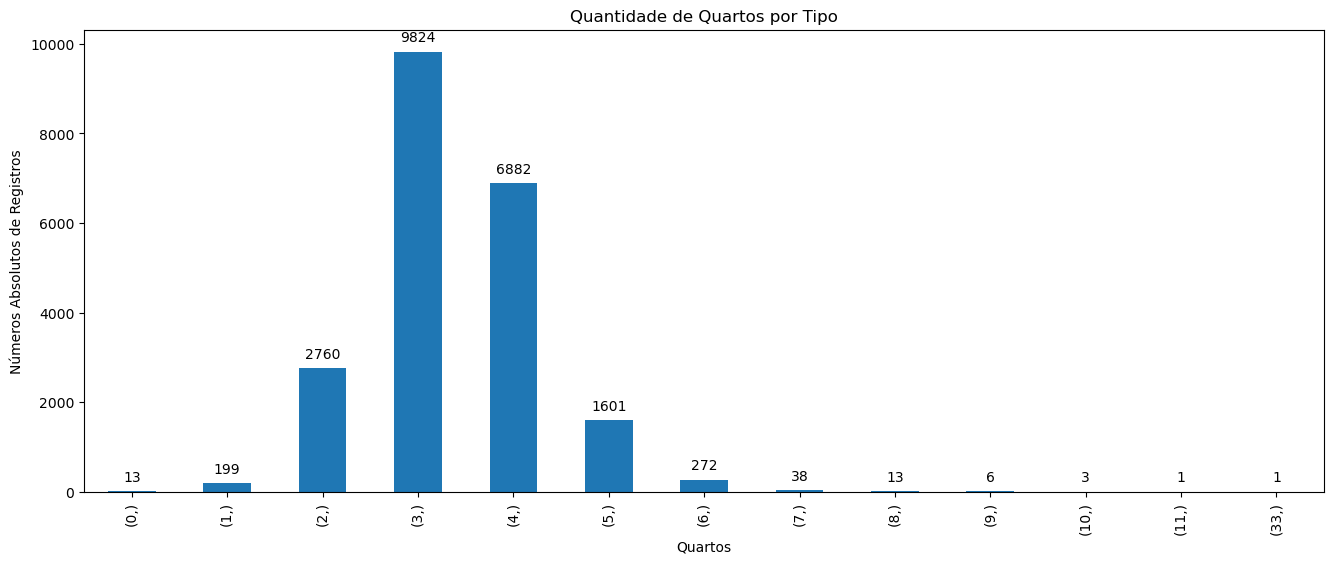

In [25]:
# Crie a figura com um tamanho específico
plt.figure(figsize=(16, 6))
# Plotar o gráfico de barras usando a série 'contagem_anos'
cont_quartos = dataset[['num_quartos']].value_counts().sort_index().plot(kind='bar')
# Adiciona rótulos ao eixo x e y
plt.xlabel('Quartos')
plt.ylabel('Números Absolutos de Registros')
# Adiciona um título ao gráfico
plt.title('Quantidade de Quartos por Tipo')

# Itera sobre cada barra (patch) no gráfico de barras
for linha in cont_quartos.patches:
    # Adiciona uma anotação (número total) acima de cada barra
    cont_quartos.annotate(
        f"{linha.get_height():.0f}",                                    # Texto formatado com a altura da barra como número inteiro
        (linha.get_x() + linha.get_width() / 2., linha.get_height()),   # Coordenadas do texto (centro da barra)
        ha='center',                                                    # Alinhamento horizontal: centralizado
        va='center',                                                    # Alinhamento vertical: centralizado
        xytext=(0, 10),                                                 # Deslocamento do texto (10 pontos acima)
        textcoords='offset points'                                      # Coordenadas do deslocamento em pontos
    )
# Exibe o gráfico
plt.show()

---

Para manter consistência estatística e aderência ao objetivo do estudo, optou-se por restringir a análise aos imóveis com 1 a 6 quartos, faixa que concentra a maior representatividade da base de dados e do mercado residencial analisado. Observa-se que imóveis com quantidades superiores apresentam baixa ocorrência amostral, caracterizando possíveis outliers ou casos muito específicos de mercado, o que pode gerar distorções nas métricas de preço, dispersão e modelagem preditiva.

Dessa forma, inicialmente não foi identificado ganho analítico relevante na manutenção desses registros, considerando que o foco principal do projeto é compreender o comportamento de preços em imóveis residenciais padrão, com maior liquidez e representatividade de mercado. A exclusão desses casos contribui para:

* Redução de ruído estatístico;
* Menor influência de valores extremos;
* Maior estabilidade das análises exploratórias e modelos preditivos;
* Melhor capacidade de generalização dos insights;
* Maior aderência ao perfil predominante do mercado analisado.

Além disso, registros muito discrepantes, como imóveis com 33 quartos, podem indicar propriedades comerciais, hotéis, pensões, erros cadastrais ou categorias que fogem do escopo originalmente definido para o estudo.


---

In [26]:
# Filtra o dataset para manter apenas imóveis com quantidade de quartos
# entre 1 e 6 (inclusive).
# Método utilizado:
# A função .between(1, 6) retorna True para valores entre
# 1 e 6, incluindo os limites.
dataset = dataset[dataset["num_quartos"].between(1, 6)]

In [27]:
dataset[['num_quartos']].value_counts().sort_index().reset_index()

,num_quartos,count
0,1,199
1,2,2760
2,3,9824
3,4,6882
4,5,1601
5,6,272


In [28]:
dataset.shape

(21538, 18)

### 2.1.5 Tratando a Variável (pontuacao_vista)

In [29]:
dataset.sample(10)

,preco_venda,num_quartos,area_util_pes2,area_terreno_pes2,possui_vista_agua,pontuacao_vista,pontuacao_condicao,classificacao_construcao,area_acima_solo_pes2,area_porao_pes2,codigo_postal,area_media_vizinhos_pes2,area_terreno_media_vizinhos_pes2,idade_imovel,banheiro_completo,banheiro_complementar,numero_andares,andar_apoio
7365,325000.0,3,1580,4007,0,0,3,7,1580,0,98019,1770,3799,25,2,1,2,0
13759,850000.0,3,3180,3680,0,0,4,9,2190,990,98126,2000,3680,108,2,1,2,0
8207,442500.0,4,1540,5920,0,0,5,7,1540,0,98125,1630,6216,91,2,0,1,1
10379,730000.0,4,2030,4080,0,0,4,8,1730,300,98115,1980,4080,105,2,1,1,1
3605,328000.0,2,700,4350,0,0,3,6,700,0,98116,1620,5100,83,1,0,1,0
21475,330000.0,3,1520,3003,0,0,3,7,1520,0,98059,1820,3030,17,2,1,2,0
18737,410000.0,5,2910,5802,0,0,3,7,2910,0,98038,2910,5000,20,2,1,2,0
9758,416000.0,4,1980,7840,0,0,4,7,990,990,98008,1520,8400,65,1,1,1,0
8834,235000.0,3,1530,8700,0,0,4,7,1530,0,98055,1960,7600,56,2,0,1,0
17398,225000.0,3,1650,7739,0,0,3,8,1290,360,98003,1650,6033,40,2,1,1,0


In [30]:
dataset['pontuacao_vista'].value_counts().sort_index().reset_index()

,pontuacao_vista,count
0,0,19427
1,1,329
2,2,956
3,3,509
4,4,317


---

A variável `pontuacao_vista` apresenta forte desbalanceamento entre as classes, com concentração extremamente elevada no valor 0, que representa aproximadamente a totalidade dos registros da base. Essa distribuição reduz significativamente a capacidade da variável em contribuir de forma relevante para a predição de preços, uma vez que o modelo tende a aprender predominantemente o comportamento da classe majoritária.

Dessa forma, os valores diferentes de zero possuem baixa representatividade estatística quando comparados ao volume total da base, o que pode gerar alguns problemas analíticos:

* Forte viés para a classe dominante;
* Baixa capacidade discriminatória da variável;
* Redução do ganho preditivo nos modelos;
* Possível introdução de ruído estatístico;
* Dificuldade de generalização para padrões minoritários.

Além disso, a predominância massiva do valor 0 sugere que a variável pode possuir baixa variabilidade informacional, limitando seu poder explicativo sobre o comportamento dos preços dos imóveis.

Inicialmente, não há evidências de que a manutenção dessa feature agregue valor proporcional à complexidade adicionada ao modelo analítico. Portanto, sua exclusão pode contribuir para uma modelagem mais robusta, reduzindo influência de distribuições altamente desbalanceadas e priorizando variáveis com maior capacidade explicativa.

---

In [31]:
# Remove permanentemente a coluna 'pontuacao_vista'
# diretamente no dataset original.
dataset.drop('pontuacao_vista', axis=1, inplace=True)

### 2.1.6 Tratando a Variável (possui_vista_agua)

In [32]:
dataset.sample(10)

,preco_venda,num_quartos,area_util_pes2,area_terreno_pes2,possui_vista_agua,pontuacao_condicao,classificacao_construcao,area_acima_solo_pes2,area_porao_pes2,codigo_postal,area_media_vizinhos_pes2,area_terreno_media_vizinhos_pes2,idade_imovel,banheiro_completo,banheiro_complementar,numero_andares,andar_apoio
19752,569950.0,4,3230,5899,0,3,8,3230,0,98065,2720,5899,14,2,1,2,0
4830,215000.0,3,1260,7897,0,3,7,1260,0,98022,1560,8285,47,1,0,1,0
21202,450800.0,4,2510,5311,0,3,9,2510,0,98056,1590,9583,17,3,1,2,0
8155,945800.0,4,3360,9100,0,4,8,1760,1600,98006,2620,8925,53,2,1,1,0
16552,1185000.0,3,2390,7875,0,3,10,1980,410,98105,3720,9075,78,2,1,1,0
7599,410000.0,4,1580,9581,0,3,7,1580,0,98033,1580,10552,73,2,0,1,0
15416,387000.0,3,1230,9568,0,5,7,1230,0,98056,1270,9575,64,1,0,1,0
8438,374900.0,5,2980,8500,0,3,8,1540,1440,98032,2310,8500,44,2,1,1,0
6944,499000.0,3,2090,8505,0,3,8,2090,0,98177,1640,8100,75,2,1,2,0
13840,320000.0,3,1650,7047,0,3,7,1650,0,98038,2010,7763,32,2,1,2,0


In [33]:
dataset['possui_vista_agua'].value_counts().sort_index().reset_index()

,possui_vista_agua,count
0,0,21375
1,1,163


---

A variável `possui_vista_agua` será removida da análise devido ao elevado nível de desbalanceamento entre suas categorias. A distribuição dos dados demonstrou predominância quase absoluta da classe `0`, representando imóveis sem vista para água, enquanto a classe `1` apresentou uma quantidade muito reduzida de ocorrências.

Essa baixa representatividade compromete a capacidade da variável em contribuir de maneira consistente para o modelo, podendo induzir padrões pouco generalizáveis e aumentar o risco de viés estatístico durante o processo de predição.

Além disso, embora possua relevância descritiva no contexto imobiliário, a variável apresenta baixa capacidade de discriminação dentro do conjunto analisado, tornando sua contribuição limitada em relação ao volume total de registros. Dessa forma, optou-se pela remoção da variável nesta etapa do projeto, priorizando maior estabilidade analítica e redução de ruídos no modelo.

---

In [34]:
# Remove permanentemente a coluna 'possui_vista_agua'
# diretamente no dataset original.
dataset.drop('possui_vista_agua', axis=1, inplace=True)

### 2.1.7 Tratando a Variável (pontuacao_condicao)

In [35]:
dataset['pontuacao_condicao'].value_counts().sort_index().reset_index()

,pontuacao_condicao,count
0,1,29
1,2,171
2,3,13980
3,4,5664
4,5,1694


---

A variável `pontuacao_condicao` será mantida na análise neste momento, pois sua distribuição, apesar de concentrada nas categorias intermediárias, não apresenta um nível crítico de desbalanceamento que comprometa sua utilização no modelo.

Observa-se predominância das categorias `3` e `4`, comportamento esperado em variáveis relacionadas à condição geral dos imóveis, já que a maior parte das propriedades tende a se concentrar em estados considerados medianos ou bons. Além disso, todas as categorias possuem representatividade dentro do conjunto de dados, inclusive as classes menos frequentes.

Por se tratar de uma variável potencialmente relevante para explicar variações no valor dos imóveis, optou-se por mantê-la nesta etapa da análise, uma vez que não foram identificados indícios significativos de viés, inconsistência estatística ou necessidade imediata de transformação ou remoção.

---

### 2.1.8 Tratando a Variável (classificacao_construcao)

In [36]:
dataset['classificacao_construcao'].value_counts().sort_index().reset_index()

,classificacao_construcao,count
0,3,3
1,4,27
2,5,242
3,6,2037
4,7,8950
5,8,6048
6,9,2609
7,10,1128
8,11,394
9,12,87


---

A variável `classificacao_construcao` apresenta atualmente uma escala de avaliação entre `3` e `13`. Apesar de a distribuição dos dados não indicar problemas significativos de representatividade entre as principais categorias, a escala utilizada possui baixa intuitividade interpretativa dentro do contexto da análise.

Considerando a necessidade de tornar a leitura dos dados mais clara e semanticamente compreensível, optou-se por realizar uma adequação da variável para uma escala mais padronizada e intuitiva, variando de `0` a `10`. Essa transformação visa melhorar a interpretabilidade das classificações, facilitar análises comparativas e tornar os resultados mais compreensíveis durante as etapas exploratórias e de modelagem.

Além disso, a padronização da escala contribui para maior consistência analítica, especialmente na interpretação de métricas, visualizações e possíveis relações entre a qualidade construtiva e o valor dos imóveis.

---

In [37]:
# Reescala a variável 'classificacao_construcao' de uma faixa entre 3 e 13
# para uma escala mais intuitiva de 0 a 10.
# Essa transformação mantém a proporcionalidade original dos valores,
# facilitando a interpretação e padronização da análise.
dataset['classificacao_construcao'] = dataset['classificacao_construcao'].replace({
    3: 0,
    4: 1,
    5: 2,
    6: 3,
    7: 4,
    8: 5,
    9: 6,
    10: 7,
    11: 8,
    12: 9,
    13: 10
})

In [38]:
dataset['classificacao_construcao'].value_counts().sort_index().reset_index()

,classificacao_construcao,count
0,0,3
1,1,27
2,2,242
3,3,2037
4,4,8950
5,5,6048
6,6,2609
7,7,1128
8,8,394
9,9,87


### 2.1.9 Tratando a Variável (codigo_postal)

In [39]:
# Configura o pandas para exibir todas as linhas no output
pd.set_option('display.max_rows', None)
dataset['codigo_postal'].value_counts().sort_index().reset_index()

,codigo_postal,count
0,98001,361
1,98002,199
2,98003,280
3,98004,313
4,98005,168
5,98006,496
6,98007,138
7,98008,282
8,98010,100
9,98011,195


---

A variável `codigo_postal` será mantida sem alterações nesta etapa da análise. Atualmente, o conjunto de dados apresenta 70 regiões distintas, o que torna a binarização da variável uma possível estratégia futura para capturar diferenças geográficas relacionadas aos valores dos imóveis.

Considerando que a localização é um dos fatores mais relevantes no mercado imobiliário, é esperado que diferentes bairros apresentem comportamentos distintos de precificação, podendo contribuir significativamente para a capacidade explicativa do modelo.

Entretanto, neste momento, vou optar por não realizar transformações na variável, uma vez que a próxima etapa do projeto será dedicada à Análise Exploratória de Dados (EDA). Além disso, a criação de variáveis binárias para cada região aumentaria consideravelmente a dimensionalidade do conjunto de dados, o que demanda uma avaliação mais aprofundada sobre impacto estatístico, relevância preditiva e custo computacional antes da implementação.


---

In [40]:
dataset.sample(10)

,preco_venda,num_quartos,area_util_pes2,area_terreno_pes2,pontuacao_condicao,classificacao_construcao,area_acima_solo_pes2,area_porao_pes2,codigo_postal,area_media_vizinhos_pes2,area_terreno_media_vizinhos_pes2,idade_imovel,banheiro_completo,banheiro_complementar,numero_andares,andar_apoio
2177,1085000.0,3,3630,11019,4,6,2150,1480,98040,3150,13555,54,2,1,1,0
3825,214946.0,3,1290,8688,4,4,1290,0,98042,1750,9090,46,1,1,1,0
1198,277000.0,2,770,8149,3,3,770,0,98155,1160,8149,78,1,0,1,0
20159,310000.0,4,2310,7384,3,5,2310,0,98042,2310,7800,16,2,1,2,0
1330,567000.0,5,2100,6936,3,5,1600,500,98033,2100,8661,52,2,1,1,0
8231,480000.0,3,1470,10052,4,5,1470,0,98125,1480,9780,70,2,0,1,0
20283,380000.0,4,2420,4981,3,6,2420,0,98038,2420,5000,17,2,1,2,0
21075,586500.0,3,1780,1487,3,5,1600,180,98107,1780,1300,20,2,1,3,0
14594,706000.0,5,2890,15891,3,6,2890,0,98059,2590,10556,36,2,1,2,0
20676,828950.0,4,3930,5680,3,6,2820,1110,98027,3700,5816,13,3,1,2,0


### 2.2.0 Tratando a Variável (area_acima_solo_pes2, area_porao_pes2, area_media_vizinhos_pes2, area_terreno_media_vizinhos_pes2)

In [41]:
# Conversão de variáveis de área de pés² para metros²
# Fator de conversão utilizado:
# 1 pé² = 0.092903 m²
# Objetivo:
# Padronizar as medidas do dataset em metros quadrados,
# facilitando análises estatísticas, visualizações e
# interpretação dos dados.

# Converte a área útil do imóvel de pés² para metros²
dataset['area_util_pes2'] = dataset['area_util_pes2'] * 0.092903
# Converte a área total do terreno de pés² para metros²
dataset['area_terreno_pes2'] = dataset['area_terreno_pes2'] * 0.092903
# Cria uma nova coluna contendo a área acima do solo em metros²
dataset['area_acima_solo_m2'] = dataset['area_acima_solo_pes2'] * 0.092903
# Cria uma nova coluna contendo a área do porão em metros²
dataset['area_porao_m2'] = dataset['area_porao_pes2'] * 0.092903
# Converte a média de área dos imóveis vizinhos para metros²
dataset['area_media_vizinhos_m2'] = dataset['area_media_vizinhos_pes2'] * 0.092903
# Converte a média da área dos terrenos vizinhos para metros²
dataset['area_terreno_media_vizinhos_m2'] = dataset['area_terreno_media_vizinhos_pes2'] * 0.092903

In [42]:
dataset[
    [   
        'area_util_pes2',
        'area_terreno_pes2',
        'area_acima_solo_m2',
        'area_porao_m2',
        'area_media_vizinhos_m2',
        'area_terreno_media_vizinhos_m2'
    ]
].head()

,area_util_pes2,area_terreno_pes2,area_acima_solo_m2,area_porao_m2,area_media_vizinhos_m2,area_terreno_media_vizinhos_m2
0,109.62554,524.901950,109.62554,0.00000,124.49002,524.901950
1,238.76071,672.803526,201.59951,37.16120,157.00607,709.686017
2,71.53531,929.030000,71.53531,0.00000,252.69616,748.983986
3,182.08988,464.515000,97.54815,84.54173,126.34808,464.515000
4,156.07704,750.656240,156.07704,0.00000,167.22540,697.051209


In [43]:
renomeando = {
    "area_util_pes2": 'area_util',                                      # área interna habitável (principal feature preditiva)
    "area_terreno_pes2": 'area_terreno',                                # área total do terreno
    "area_acima_solo_pes2": 'area_acima_solo',                          # área acima do nível do solo
    "area_porao_pes2": 'area_porao',                                    # área do porão
    "area_media_vizinhos_pes2": 'area_media_vizinhos',                  # média da área útil das casas vizinhas (contexto regional)
    "area_terreno_media_vizinhos_pes2": 'area_terreno_media_vizinhos'   # média da área de terreno da vizinhança
}
# aplica a renomeação das colunas no dataset
dataset = dataset.rename(columns=renomeando)

## 2.3 Reorganizando Variáveis

In [44]:
dataset.columns

Index(['preco_venda', 'num_quartos', 'area_util', 'area_terreno',
       'pontuacao_condicao', 'classificacao_construcao', 'area_acima_solo',
       'area_porao', 'codigo_postal', 'area_media_vizinhos',
       'area_terreno_media_vizinhos', 'idade_imovel', 'banheiro_completo',
       'banheiro_complementar', 'numero_andares', 'andar_apoio',
       'area_acima_solo_m2', 'area_porao_m2', 'area_media_vizinhos_m2',
       'area_terreno_media_vizinhos_m2'],
      dtype='object')

In [45]:
# Lista com a ordem desejada das variáveis, organizada de forma mais intuitiva:
# 1. Características internas do imóvel
# 2. Estrutura física
# 3. Áreas do imóvel
# 4. Informações de localização e contexto
# 5. Variável alvo ao final

dados_organizados = [
    # Características internas
    'num_quartos',
    'banheiro_completo',
    'banheiro_complementar',
    'numero_andares',
    'andar_apoio',
    
    # Qualidade e condição
    'pontuacao_condicao',
    'classificacao_construcao',
    'idade_imovel',
    
    # Áreas internas
    'area_util',
    'area_acima_solo',
    'area_porao',
    
    # Área externa
    'area_terreno',
    
    # Informações da vizinhança
    'area_media_vizinhos',
    'area_terreno_media_vizinhos',
    
    # Localização
    'codigo_postal',
    
    # Variável alvo
    'preco_venda'
]
# Reorganiza as colunas do dataset conforme a ordem definida acima
dataset = dataset.reindex(columns=dados_organizados)

In [46]:
dataset.sample(10)

,num_quartos,banheiro_completo,banheiro_complementar,numero_andares,andar_apoio,pontuacao_condicao,classificacao_construcao,idade_imovel,area_util,area_acima_solo,area_porao,area_terreno,area_media_vizinhos,area_terreno_media_vizinhos,codigo_postal,preco_venda
2367,3,1,1,2,0,3,6,98,206.24466,1790,430,448.721490,1670,4830,98116,1101000.0
300,4,5,0,1,0,3,7,24,422.70865,2600,1950,1731.804823,4550,19508,98074,3075000.0
7947,3,2,0,1,0,4,4,37,153.28995,1650,0,736.720790,1510,7930,98038,251000.0
10908,2,1,0,1,0,4,4,87,104.05136,1120,0,691.198320,1170,7440,98155,335900.0
14804,3,2,1,2,0,3,4,31,172.79958,1860,0,1043.021981,1820,8800,98038,330000.0
18792,3,2,1,1,0,3,6,37,236.90265,2550,0,797.850964,3050,8588,98011,490000.0
3426,3,2,0,1,1,5,4,119,157.00607,1690,0,473.805300,1690,5100,98117,515000.0
7053,4,2,1,2,0,3,7,31,303.79281,3270,0,857.587593,3380,10154,98052,940000.0
17340,3,1,0,1,0,3,4,57,93.83203,1010,0,883.879142,1010,9514,98059,270000.0
20654,3,3,0,3,0,3,5,17,127.27711,1370,0,92.995903,1399,1151,98133,327000.0


In [47]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
Index: 21538 entries, 0 to 21612
Data columns (total 16 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   num_quartos                  21538 non-null  int64  
 1   banheiro_completo            21538 non-null  int64  
 2   banheiro_complementar        21538 non-null  int64  
 3   numero_andares               21538 non-null  int64  
 4   andar_apoio                  21538 non-null  int64  
 5   pontuacao_condicao           21538 non-null  int64  
 6   classificacao_construcao     21538 non-null  int64  
 7   idade_imovel                 21538 non-null  int32  
 8   area_util                    21538 non-null  float64
 9   area_acima_solo              21538 non-null  int64  
 10  area_porao                   21538 non-null  int64  
 11  area_terreno                 21538 non-null  float64
 12  area_media_vizinhos          21538 non-null  int64  
 13  area_terreno_media_vi

# 3.0 Exploratory Data Analysis (EDA)


## 3.1 Tabela Discricionária

In [48]:
verificando_valores = round(dataset.drop('codigo_postal', axis=1).describe().T,2)
verificando_valores

,count,mean,std,min,25%,50%,75%,max
num_quartos,21538.0,3.36,0.88,1.00,3.00,3.00,4.00,6.00
banheiro_completo,21538.0,1.75,0.73,0.00,1.00,2.00,2.00,8.00
banheiro_complementar,21538.0,0.69,0.46,0.00,0.00,1.00,1.00,1.00
numero_andares,21538.0,1.45,0.55,1.00,1.00,1.00,2.00,3.00
andar_apoio,21538.0,0.10,0.29,0.00,0.00,0.00,0.00,1.00
pontuacao_condicao,21538.0,3.41,0.65,1.00,3.00,3.00,4.00,5.00
classificacao_construcao,21538.0,4.66,1.17,0.00,4.00,4.00,5.00,10.00
idade_imovel,21538.0,54.96,29.36,11.00,29.00,51.00,75.00,126.00
area_util,21538.0,192.78,84.52,34.37,131.92,177.44,235.97,1119.48
area_acima_solo,21538.0,1785.09,823.30,370.00,1190.00,1560.00,2210.00,8860.00


**Insights Encontrados**

Estrutura dos Imóveis

* A maioria dos imóveis possui entre 3 e 4 quartos.
* Predominam casas com 1 ou 2 banheiros completos e até 2 andares.
* Poucos imóveis possuem andar de apoio ou porão.

Condição e Qualidade

* Os imóveis apresentam condição média considerada boa.
* A classificação das construções concentra-se em padrões medianos, com presença de imóveis de alto padrão.

Idade dos Imóveis

* A idade média dos imóveis é de aproximadamente 55 anos.
* Existem imóveis bastante antigos, chegando a mais de 120 anos.

Áreas dos Imóveis

* A área útil média é de aproximadamente 193 m².
* As variáveis relacionadas à área apresentam grande dispersão e presença de outliers.
* O tamanho dos terrenos vizinhos varia significativamente entre regiões.

Preço de Venda

* O preço médio é superior à mediana, indicando assimetria positiva.
* Existem imóveis de alto valor que elevam significativamente a média do dataset.
* O valor máximo ultrapassa 7 milhões.

---

## 3.2 Comparando Variáveis com a Variável (preco_venda)

### 3.2.1 Comparando Variável num_quartos X preco_venda

In [49]:
preco_medio_por_quarto = round(dataset.groupby(['num_quartos'])['preco_venda'].mean(),2)
preco_medio_por_quarto.reset_index()

,num_quartos,preco_venda
0,1,317642.88
1,2,401372.68
2,3,466232.08
3,4,635419.50
4,5,786599.83
5,6,825520.64


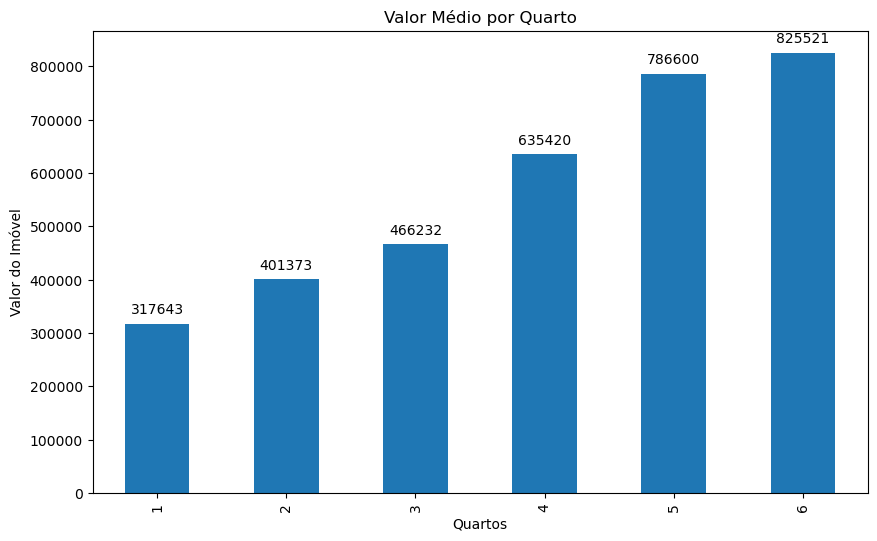

In [50]:
# Crie a figura com um tamanho específico
plt.figure(figsize=(10, 6))
# Plotar o gráfico de barras usando a série 'preco_medio_por_quarto'
preco_medio_por_quarto = round(dataset.groupby(['num_quartos'])['preco_venda'].mean(),2).sort_index().plot(kind='bar')
# Adiciona rótulos ao eixo x e y
plt.xlabel('Quartos')
plt.ylabel('Valor do Imóvel')
# Adiciona um título ao gráfico
plt.title('Valor Médio por Quarto')

# Itera sobre cada barra (patch) no gráfico de barras
for linha in preco_medio_por_quarto.patches:
    # Adiciona uma anotação (número total) acima de cada barra
    preco_medio_por_quarto.annotate(
        f"{linha.get_height():.0f}",                                    # Texto formatado com a altura da barra como número inteiro
        (linha.get_x() + linha.get_width() / 2., linha.get_height()),   # Coordenadas do texto (centro da barra)
        ha='center',                                                    # Alinhamento horizontal: centralizado
        va='center',                                                    # Alinhamento vertical: centralizado
        xytext=(0, 10),                                                 # Deslocamento do texto (10 pontos acima)
        textcoords='offset points'                                      # Coordenadas do deslocamento em pontos
    )

# Exibe o gráfico
plt.show()

---

A variável `num_quartos` apresenta uma relação positiva e consistente com o `preco_venda`, indicando que imóveis com maior quantidade de quartos tendem a possuir maior valor de mercado.

Principais observações:

* Imóveis com:

  * **1 quarto** possuem preço médio próximo de **R$ 318 mil**;
  * **2 quartos** já apresentam aumento para cerca de **R$ 401 mil**;
  * **3 quartos** alcançam aproximadamente **R$ 466 mil**.

* O crescimento se torna ainda mais evidente em imóveis maiores:

  * **4 quartos** ultrapassam **R$ 635 mil**;
  * **5 quartos** chegam próximos de **R$ 787 mil**;
  * **6 quartos** apresentam média superior a **R$ 825 mil**.

A análise sugere que:

* o número de quartos é um importante indicador de tamanho, capacidade e padrão do imóvel;
* imóveis com mais dormitórios costumam atender perfis familiares maiores e segmentos de maior poder aquisitivo.

Outro ponto relevante:

* Embora o preço continue aumentando, o crescimento entre 5 e 6 quartos ocorre de forma mais moderada, indicando possível redução no ganho marginal por quarto adicional.

Em resumo:

* Existe forte associação entre quantidade de quartos e valorização imobiliária;
* `num_quartos` tende a ser uma variável relevante e explicativa em modelos de previsão de preço;
* imóveis maiores, com mais dormitórios, estão concentrados em faixas de maior valor agregado.


---

### 3.2.2 Comparando Variável banheiro_completo/banheiro_complementar X preco_venda

In [51]:
preco_medio_por_banheiro = round(dataset.groupby(['banheiro_completo', 'banheiro_complementar'])['preco_venda'].mean(),2)
preco_medio_por_banheiro.reset_index()

,banheiro_completo,banheiro_complementar,preco_venda
0,0,0,279666.67
1,0,1,291866.69
2,1,0,347086.71
3,1,1,440582.61
4,2,0,457790.13
5,2,1,563457.09
6,3,0,707015.69
7,3,1,975438.33
8,4,0,1276238.36
9,4,1,1489348.66


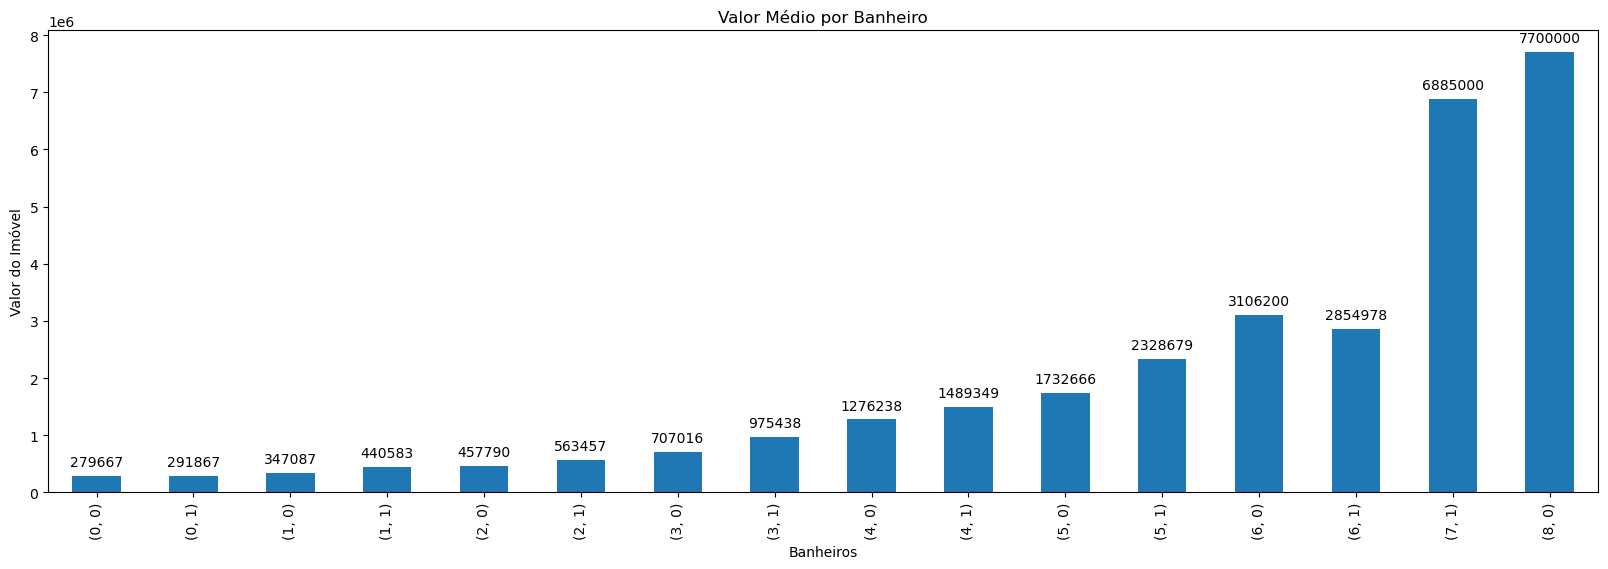

In [52]:
# Crie a figura com um tamanho específico
plt.figure(figsize=(20, 6))
# Plotar o gráfico de barras usando a série 'preco_medio_por_banheiro'
preco_medio_por_banheiro = round(dataset.groupby(['banheiro_completo', 'banheiro_complementar'])['preco_venda'].mean(),2).plot(kind='bar')
# Adiciona rótulos ao eixo x e y
plt.xlabel('Banheiros')
plt.ylabel('Valor do Imóvel')
# Adiciona um título ao gráfico
plt.title('Valor Médio por Banheiro')

# Itera sobre cada barra (patch) no gráfico de barras
for linha in preco_medio_por_banheiro.patches:
    # Adiciona uma anotação (número total) acima de cada barra
    preco_medio_por_banheiro.annotate(
        f"{linha.get_height():.0f}",                                    # Texto formatado com a altura da barra como número inteiro
        (linha.get_x() + linha.get_width() / 2., linha.get_height()),   # Coordenadas do texto (centro da barra)
        ha='center',                                                    # Alinhamento horizontal: centralizado
        va='center',                                                    # Alinhamento vertical: centralizado
        xytext=(0, 10),                                                 # Deslocamento do texto (10 pontos acima)
        textcoords='offset points'                                      # Coordenadas do deslocamento em pontos
    )

# Exibe o gráfico
plt.show()

---

A análise das variáveis `banheiro_completo` e `banheiro_complementar` mostra uma forte relação positiva com o `preco_venda`, indicando que a quantidade de banheiros é um dos fatores mais relevantes para valorização do imóvel.

Principais insights:

* Existe uma tendência clara de aumento do preço conforme cresce o número de `banheiro_completo`.
* Imóveis com poucos banheiros (0 ou 1) apresentam valores médios entre aproximadamente **R$ 280 mil e R$ 440 mil**.
* Já imóveis com maior quantidade de banheiros completos atingem valores muito superiores, ultrapassando:

  * **R$ 1 milhão** a partir de 4 banheiros;
  * **R$ 3 milhões** com 6 banheiros;
  * até **R$ 7,7 milhões** nos imóveis mais luxuosos.

Sobre `banheiro_complementar`:

* A presença de banheiro complementar geralmente aumenta ainda mais o valor médio do imóvel.
* Em praticamente todas as faixas de `banheiro_completo`, imóveis com `banheiro_complementar = 1` possuem preços superiores aos equivalentes sem essa característica.
* Isso sugere que banheiros adicionais funcionam como diferencial de conforto e padrão elevado.

Outro ponto importante:

* O crescimento do preço não é linear; ele se acelera nos imóveis de alto padrão.
* A partir de 3 ou 4 banheiros completos, os preços passam a crescer de forma muito mais intensa, indicando forte associação com imóveis de luxo.

Em resumo:

* Quantidade de banheiros é uma variável altamente correlacionada ao valor do imóvel.
* `banheiro_complementar` agrega valor adicional ao imóvel.
* Essas variáveis provavelmente terão alta importância em modelos preditivos de precificação imobiliária.


---


### 3.2.3 Comparando Variável numero_andares/andar_apoio X preco_venda

In [53]:
preco_medio_por_andares = round(dataset.groupby(['numero_andares', 'andar_apoio'])['preco_venda'].mean(),2)
preco_medio_por_andares.reset_index()

,numero_andares,andar_apoio,preco_venda
0,1,0,441964.54
1,1,1,558508.48
2,2,0,647889.86
3,2,1,1035864.88
4,3,0,580558.13
5,3,1,511916.67


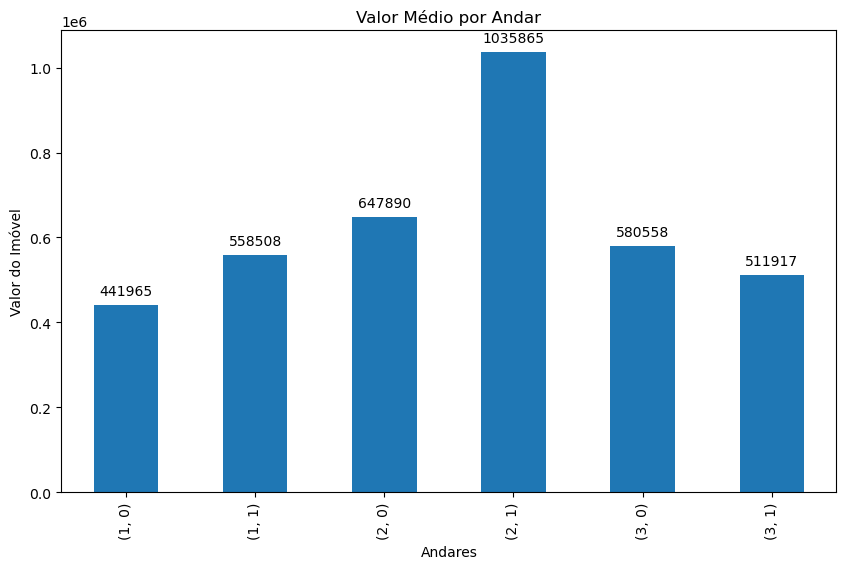

In [54]:
# Crie a figura com um tamanho específico
plt.figure(figsize=(10, 6))
# Plotar o gráfico de barras usando a série 'preco_medio_por_andares'
preco_medio_por_andares = round(dataset.groupby(['numero_andares', 'andar_apoio'])['preco_venda'].mean(),2).plot(kind='bar')
# Adiciona rótulos ao eixo x e y
plt.xlabel('Andares')
plt.ylabel('Valor do Imóvel')
# Adiciona um título ao gráfico
plt.title('Valor Médio por Andar')

# Itera sobre cada barra (patch) no gráfico de barras
for linha in preco_medio_por_andares.patches:
    # Adiciona uma anotação (número total) acima de cada barra
    preco_medio_por_andares.annotate(
        f"{linha.get_height():.0f}",                                    # Texto formatado com a altura da barra como número inteiro
        (linha.get_x() + linha.get_width() / 2., linha.get_height()),   # Coordenadas do texto (centro da barra)
        ha='center',                                                    # Alinhamento horizontal: centralizado
        va='center',                                                    # Alinhamento vertical: centralizado
        xytext=(0, 10),                                                 # Deslocamento do texto (10 pontos acima)
        textcoords='offset points'                                      # Coordenadas do deslocamento em pontos
    )
# Exibe o gráfico
plt.show()


----

A análise dessas variáveis sugere uma relação interessante entre estrutura do imóvel e preço de venda.

* Imóveis com apenas **1 andar** apresentam preços mais baixos em média, variando aproximadamente entre **R$ 442 mil e R$ 558 mil**.
* Quando o imóvel possui **2 andares**, observa-se um aumento significativo no valor de venda, chegando a ultrapassar **R$ 1 milhão** quando existe **andar de apoio**.
* Já os imóveis com **3 andares** mostram comportamento menos linear, indicando que apenas aumentar o número de andares não garante valorização proporcional.

Sobre a variável **andar_apoio**:

* A presença de um andar de apoio parece estar associada a imóveis de maior valor agregado em alguns casos.
* O maior preço observado no exemplo ocorre justamente em um imóvel com:

  * `numero_andares = 2`
  * `andar_apoio = 1`

Isso pode indicar que o mercado valoriza:

* espaços adicionais,
* áreas funcionais extras,
* ou maior versatilidade do imóvel.

No entanto, os dados também mostram que essa relação não é totalmente uniforme, sugerindo que outras variáveis — como metragem, localização, padrão do imóvel e quantidade de quartos — provavelmente exercem influência relevante no preço final.

Em resumo:

* Existe uma tendência de valorização conforme aumenta a complexidade estrutural do imóvel.
* O `andar_apoio` pode atuar como diferencial competitivo.
* Porém, o impacto no `preco_venda` não é isolado e deve ser analisado em conjunto com outras características do imóvel.


----


### 3.2.4 Comparando Variável pontuacao_condicao X preco_venda

In [55]:
preco_medio_por_pontuacao_condicao = round(dataset.groupby(['pontuacao_condicao'])['preco_venda'].mean(),2)
preco_medio_por_pontuacao_condicao.reset_index()

,pontuacao_condicao,preco_venda
0,1,341067.24
1,2,327867.77
2,3,541047.71
3,4,520485.86
4,5,608189.59


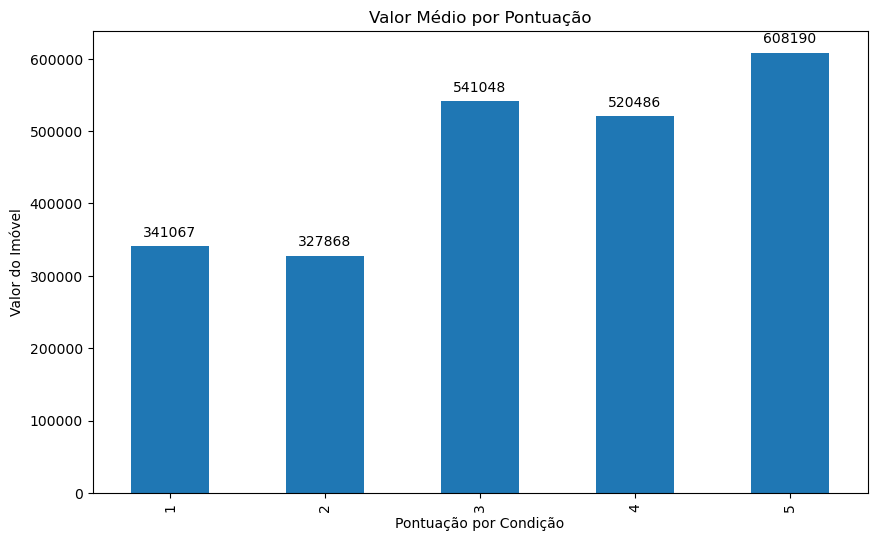

In [56]:
# Crie a figura com um tamanho específico
plt.figure(figsize=(10, 6))
# Plotar o gráfico de barras usando a série 'preco_medio_por_andares'
preco_medio_por_pontuacao_condicao = round(dataset.groupby(['pontuacao_condicao'])['preco_venda'].mean(),2).plot(kind='bar')
# Adiciona rótulos ao eixo x e y
plt.xlabel('Pontuação por Condição')
plt.ylabel('Valor do Imóvel')
# Adiciona um título ao gráfico
plt.title('Valor Médio por Pontuação')

# Itera sobre cada barra (patch) no gráfico de barras
for linha in preco_medio_por_pontuacao_condicao.patches:
    # Adiciona uma anotação (número total) acima de cada barra
    preco_medio_por_pontuacao_condicao.annotate(
        f"{linha.get_height():.0f}",                                    # Texto formatado com a altura da barra como número inteiro
        (linha.get_x() + linha.get_width() / 2., linha.get_height()),   # Coordenadas do texto (centro da barra)
        ha='center',                                                    # Alinhamento horizontal: centralizado
        va='center',                                                    # Alinhamento vertical: centralizado
        xytext=(0, 10),                                                 # Deslocamento do texto (10 pontos acima)
        textcoords='offset points'                                      # Coordenadas do deslocamento em pontos
    )
# Exibe o gráfico
plt.show()

----


A variável `pontuacao_condicao` demonstra uma relação relativamente clara com o `preco_venda`, indicando que a condição geral do imóvel influencia diretamente sua valorização.

* Imóveis com condição mais baixa (`1` e `2`) apresentam os menores preços médios, próximos de **R$ 330 mil a R$ 340 mil**.
* A partir da pontuação `3`, ocorre um salto significativo no valor médio de venda, ultrapassando **R$ 540 mil**.
* Imóveis classificados com condição `5` apresentam o maior preço médio, chegando a aproximadamente **R$ 608 mil**.

Apesar disso, existe uma pequena oscilação entre as categorias `3` e `4`, onde a pontuação `4` apresenta valor ligeiramente inferior. Isso sugere que:

* a relação não é perfeitamente linear,
* ou que outras variáveis do imóvel também impactam o preço final.

De forma geral, a análise indica que:

* melhores condições estruturais e de conservação tendem a aumentar o valor do imóvel;
* imóveis bem avaliados pelo critério de condição possuem maior percepção de valor no mercado;
* `pontuacao_condicao` provavelmente é uma variável relevante para modelos preditivos de preço de imóveis.


----

### 3.2.5 Comparando Variável classificacao_construcao X preco_venda

In [57]:
dataset.head()

,num_quartos,banheiro_completo,banheiro_complementar,numero_andares,andar_apoio,pontuacao_condicao,classificacao_construcao,idade_imovel,area_util,area_acima_solo,area_porao,area_terreno,area_media_vizinhos,area_terreno_media_vizinhos,codigo_postal,preco_venda
0,3,1,0,1,0,3,4,71,109.62554,1180,0,524.901950,1340,5650,98178,221900.0
1,3,2,1,2,0,3,4,75,238.76071,2170,400,672.803526,1690,7639,98125,538000.0
2,2,1,0,1,0,3,3,93,71.53531,770,0,929.030000,2720,8062,98028,180000.0
3,4,3,0,1,0,5,4,61,182.08988,1050,910,464.515000,1360,5000,98136,604000.0
4,3,2,0,1,0,3,5,39,156.07704,1680,0,750.656240,1800,7503,98074,510000.0


In [58]:
preco_medio_por_pontuacao_classificacao_construcao = round(dataset.groupby(['classificacao_construcao'])['preco_venda'].mean(),2)
preco_medio_por_pontuacao_classificacao_construcao.reset_index()

,classificacao_construcao,preco_venda
0,0,205666.67
1,1,212001.85
2,2,248523.97
3,3,301783.12
4,4,402190.75
5,5,542347.46
6,6,772691.14
7,7,1068455.14
8,8,1490964.08
9,9,2187750.92


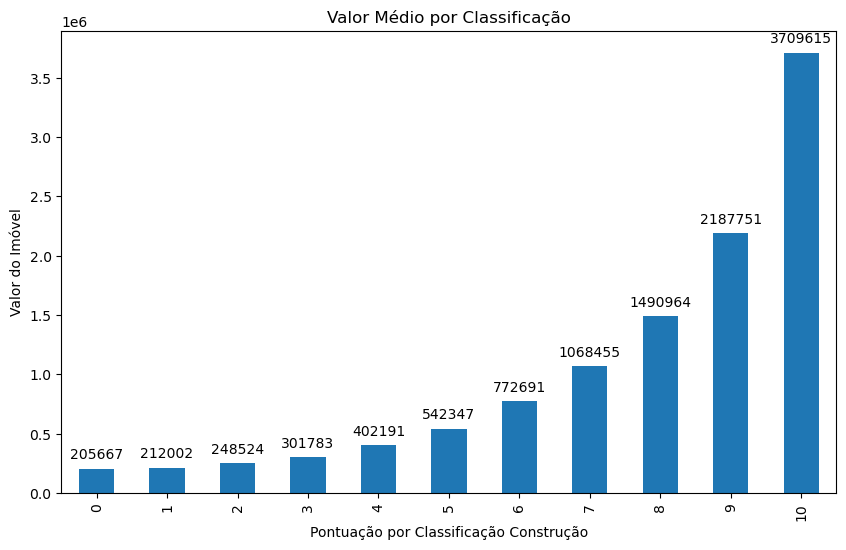

In [59]:
# Crie a figura com um tamanho específico
plt.figure(figsize=(10, 6))
# Plotar o gráfico de barras usando a série 'preco_medio_por_andares'
preco_medio_por_pontuacao_classificacao_construcao = round(dataset.groupby(['classificacao_construcao'])['preco_venda'].mean(),2).plot(kind='bar')
# Adiciona rótulos ao eixo x e y
plt.xlabel('Pontuação por Classificação Construção')
plt.ylabel('Valor do Imóvel')
# Adiciona um título ao gráfico
plt.title('Valor Médio por Classificação')

# Itera sobre cada barra (patch) no gráfico de barras
for linha in preco_medio_por_pontuacao_classificacao_construcao.patches:
    # Adiciona uma anotação (número total) acima de cada barra
    preco_medio_por_pontuacao_classificacao_construcao.annotate(
        f"{linha.get_height():.0f}",                                    # Texto formatado com a altura da barra como número inteiro
        (linha.get_x() + linha.get_width() / 2., linha.get_height()),   # Coordenadas do texto (centro da barra)
        ha='center',                                                    # Alinhamento horizontal: centralizado
        va='center',                                                    # Alinhamento vertical: centralizado
        xytext=(0, 10),                                                 # Deslocamento do texto (10 pontos acima)
        textcoords='offset points'                                      # Coordenadas do deslocamento em pontos
    )
# Exibe o gráfico
plt.show()

---

A variável `classificacao_construcao` apresenta uma das relações mais fortes e consistentes com o `preco_venda`, demonstrando que a qualidade construtiva do imóvel influencia diretamente sua valorização no mercado.

Principais insights:

* Imóveis com classificações mais baixas (`0` a `2`) possuem preços médios entre aproximadamente **R$ 205 mil e R$ 248 mil**.
* Conforme a classificação aumenta, observa-se crescimento contínuo e acelerado no valor de venda:

  * classificação `5` → cerca de **R$ 542 mil**;
  * classificação `7` → acima de **R$ 1 milhão**;
  * classificação `9` → aproximadamente **R$ 2,18 milhões**;
  * classificação `10` → ultrapassa **R$ 3,7 milhões**.

A análise sugere que:

* imóveis com melhor padrão construtivo possuem maior percepção de qualidade, conforto e sofisticação;
* a variável provavelmente representa diferenças relevantes em:

  * acabamento,
  * materiais utilizados,
  * arquitetura,
  * padrão estrutural,
  * e nível de luxo do imóvel.

Outro ponto importante:

* O crescimento do preço ocorre de forma exponencial nas classificações mais altas.
* Isso indica que pequenas melhorias em imóveis premium podem gerar aumentos muito significativos no valor de mercado.

Em resumo:

* `classificacao_construcao` é uma variável altamente explicativa do preço de venda;
* existe forte correlação positiva entre qualidade construtiva e valorização imobiliária;
* essa variável provavelmente terá grande peso em modelos preditivos de precificação.


---

### 3.2.6 Comparando Variável idade_imovel X preco_venda

In [60]:
dataset['faixa_idade'] = pd.cut(
    dataset['idade_imovel'],
    bins=[10,20,30,50,80,121],
    labels=[
        '11-20',
        '21-30',
        '31-50',
        '51-80',
        '81-121'
    ]
)

In [61]:
# Configura o pandas para exibir todas as linhas no output
pd.set_option('display.max_rows', None)

# Agrupa os dados pela idade do imóvel
# e calcula o preço médio de venda para cada idade
preco_medio_por_idade_imovel = round(dataset.groupby('faixa_idade')['preco_venda'].mean(),2)

# Converte o resultado de Series para DataFrame
# reorganizando o índice em coluna
preco_medio_por_idade_imovel.reset_index()

C:\Users\r2d2s\AppData\Local\Temp\ipykernel_908\1186327902.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  preco_medio_por_idade_imovel = round(dataset.groupby('faixa_idade')['preco_venda'].mean(),2)


,faixa_idade,preco_venda
0,11-20,621143.56
1,21-30,615645.43
2,31-50,525496.42
3,51-80,470032.37
4,81-121,561042.83


C:\Users\r2d2s\AppData\Local\Temp\ipykernel_908\2456170664.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  preco_medio_por_idade_imovel = round(dataset.groupby('faixa_idade')['preco_venda'].mean(),2).plot(kind='bar')


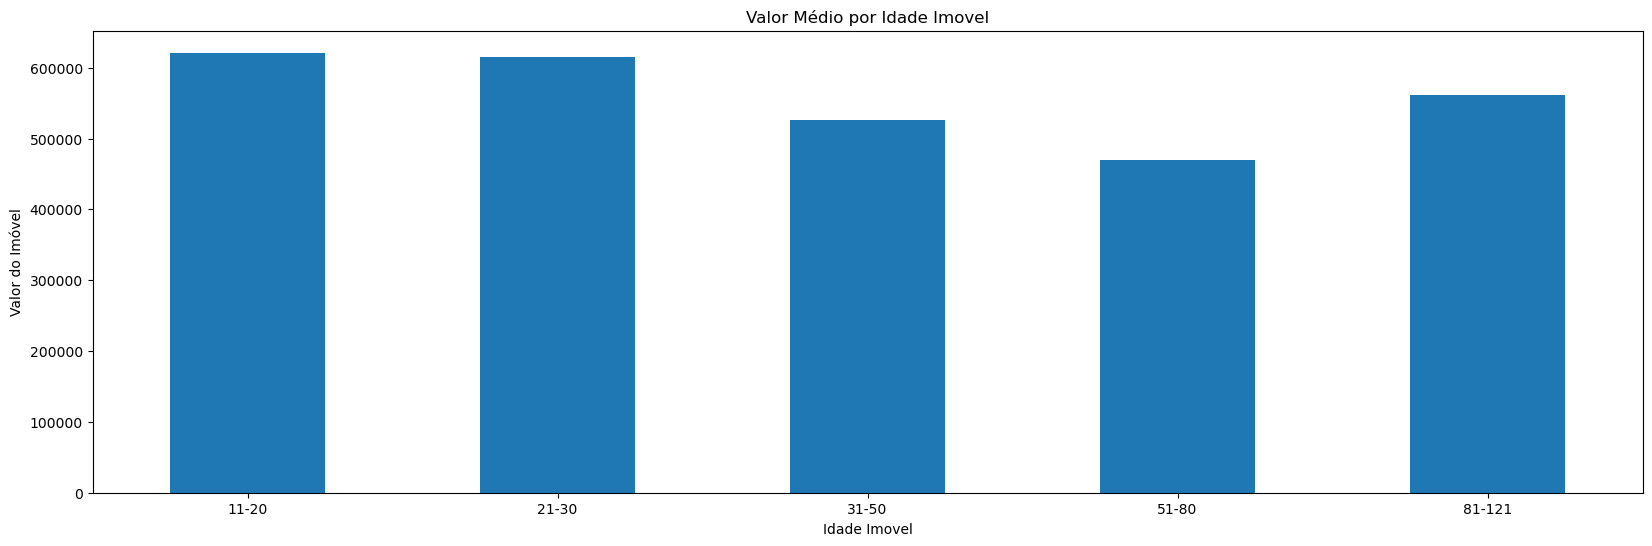

In [62]:
# Crie a figura com um tamanho específico
plt.figure(figsize=(20, 6))
# Plotar o gráfico de barras usando a série 'preco_medio_por_andares'
preco_medio_por_idade_imovel = round(dataset.groupby('faixa_idade')['preco_venda'].mean(),2).plot(kind='bar')
# Adiciona rótulos ao eixo x e y
plt.xlabel('Idade Imovel')
plt.ylabel('Valor do Imóvel')
# Adiciona um título ao gráfico
plt.title('Valor Médio por Idade Imovel')

# Itera sobre cada barra (patch) no gráfico de barras
for linha in preco_medio_por_pontuacao_classificacao_construcao.patches:
    # Adiciona uma anotação (número total) acima de cada barra
    preco_medio_por_pontuacao_classificacao_construcao.annotate(
        f"{linha.get_height():.0f}",                                    # Texto formatado com a altura da barra como número inteiro
        (linha.get_x() + linha.get_width() / 2., linha.get_height()),   # Coordenadas do texto (centro da barra)
        ha='center',                                                    # Alinhamento horizontal: centralizado
        va='center',                                                    # Alinhamento vertical: centralizado
        xytext=(0, 10),                                                 # Deslocamento do texto (10 pontos acima)
        textcoords='offset points'                                      # Coordenadas do deslocamento em pontos
    )
plt.xticks(rotation=0)
# Exibe o gráfico
plt.show()

---

A análise detalhada da variável `idade_imovel` mostra que sua relação com o `preco_venda` é relativamente complexa e não linear.

Principais insights:

* Imóveis mais novos (idades entre 11 e 30 anos) tendem a apresentar valores médios mais elevados, frequentemente acima de **R$ 600 mil**, com alguns picos superiores a **R$ 700 mil**.
* Entre aproximadamente 40 e 80 anos, observa-se uma redução gradual no valor médio, concentrando muitos imóveis na faixa entre **R$ 430 mil e R$ 550 mil**.
* As menores médias aparecem próximas das idades:

  * `82 anos` → cerca de **R$ 356 mil**;
  * `83 anos` → aproximadamente **R$ 333 mil**.

Entretanto, após os 85 anos, ocorre um comportamento interessante:

* alguns imóveis antigos voltam a apresentar forte valorização;
* há picos relevantes acima de:

  * **R$ 650 mil**,
  * **R$ 750 mil**,
  * e até **R$ 772 mil**.

Esse comportamento sugere que:

* imóveis muito antigos podem pertencer a regiões nobres,
* possuir características históricas,
* arquitetura diferenciada,
* terrenos maiores,
* ou alto potencial de valorização urbana.

Outro ponto importante:

* A variável apresenta elevada dispersão, indicando que idade isoladamente não explica totalmente o preço.
* O efeito da idade provavelmente depende de interação com:

  * localização,
  * padrão construtivo,
  * estado de conservação,
  * reformas,
  * e tamanho do imóvel.

Em resumo:

* Existe tendência parcial de desvalorização conforme o imóvel envelhece;
* porém essa relação não é contínua nem uniforme;
* imóveis antigos premium conseguem manter ou recuperar alto valor de mercado;
* `idade_imovel` parece ser uma variável de impacto moderado, funcionando melhor em conjunto com outras variáveis estruturais e de localização.


---

In [63]:
# Remove a coluna 'faixa_idade' do DataFrame original
dataset.drop('faixa_idade', axis=1, inplace=True) 

### 3.2.7 Comparando Variável area_util X preco_venda

In [64]:
bins = list(range(30, 1170, 50)) + [1170]  # Cria intervalos de 50 em 50 até o valor máximo

labels = [f'{bins[i]}-{bins[i+1]}' for i in range(len(bins)-1)]  # Cria os rótulos automaticamente

dataset['faixa_area_util'] = pd.cut(  # Cria faixas categóricas para a variável 'area_util'
    dataset['area_util'],             # Coluna numérica que será segmentada
    bins=bins,                        # Define os intervalos das faixas
    labels=labels                     # Define os rótulos automaticamente
)

In [65]:
preco_medio_por_area_util = round(dataset.groupby(['faixa_area_util'])['preco_venda'].mean(),2)
round(preco_medio_por_area_util.reset_index())

C:\Users\r2d2s\AppData\Local\Temp\ipykernel_908\821077375.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  preco_medio_por_area_util = round(dataset.groupby(['faixa_area_util'])['preco_venda'].mean(),2)


,faixa_area_util,preco_venda
0,30-80,277935.0
1,80-130,346779.0
2,130-180,419643.0
3,180-230,516979.0
4,230-280,654071.0
5,280-330,823771.0
6,330-380,1026294.0
7,380-430,1323565.0
8,430-480,1596923.0
9,480-530,1753025.0


C:\Users\r2d2s\AppData\Local\Temp\ipykernel_908\1512295768.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  preco_medio_por_faixa_area_util = round(dataset.groupby('faixa_area_util')['preco_venda'].mean(),2).plot(kind='bar')


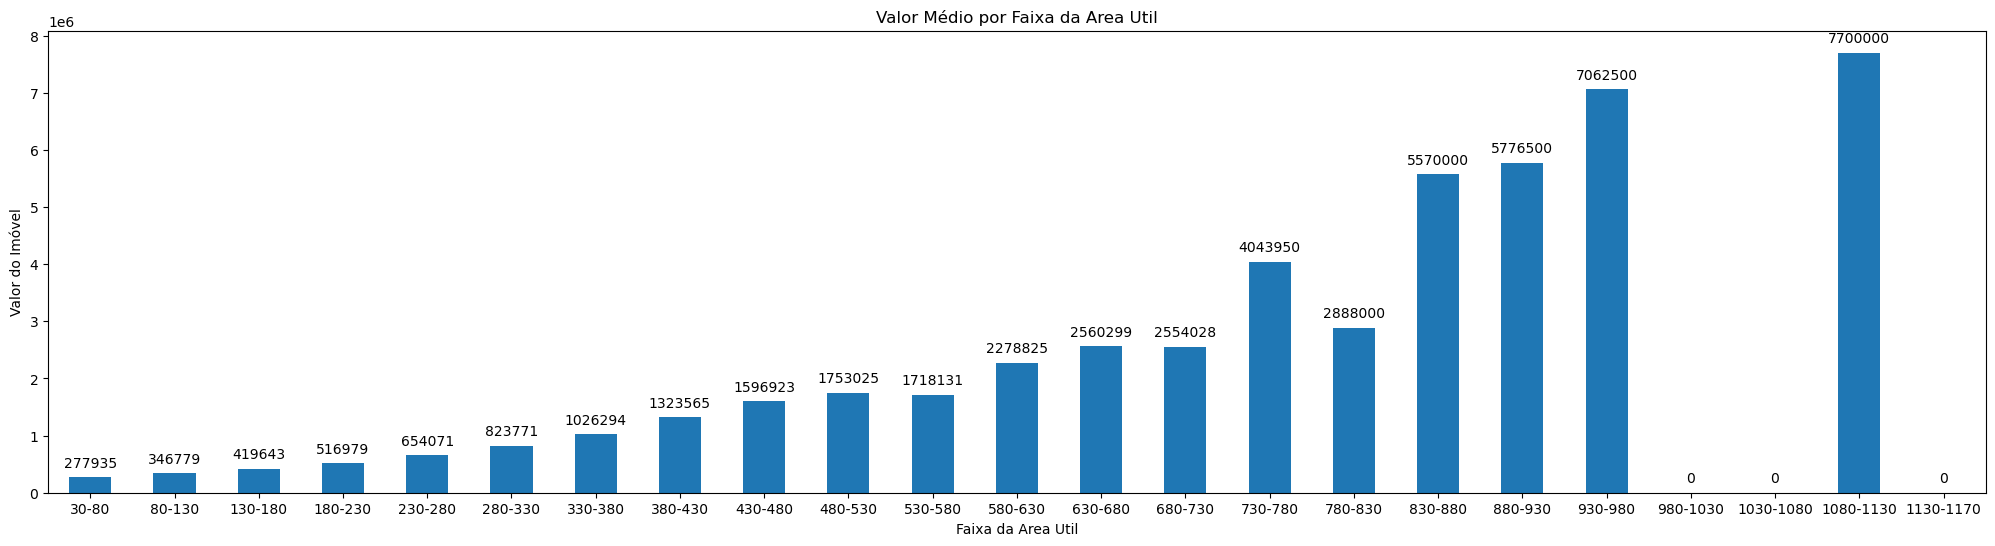

In [66]:
# Crie a figura com um tamanho específico
plt.figure(figsize=(25, 6))
# Plotar o gráfico de barras usando a série 'preco_medio_por_andares'
preco_medio_por_faixa_area_util = round(dataset.groupby('faixa_area_util')['preco_venda'].mean(),2).plot(kind='bar')
# Adiciona rótulos ao eixo x e y
plt.xlabel('Faixa da Area Util')
plt.ylabel('Valor do Imóvel')
# Adiciona um título ao gráfico
plt.title('Valor Médio por Faixa da Area Util')

# Itera sobre cada barra (patch) no gráfico de barras
for linha in preco_medio_por_faixa_area_util.patches:
    # Adiciona uma anotação (número total) acima de cada barra
    preco_medio_por_faixa_area_util.annotate(
        f"{linha.get_height():.0f}",                                    # Texto formatado com a altura da barra como número inteiro
        (linha.get_x() + linha.get_width() / 2., linha.get_height()),   # Coordenadas do texto (centro da barra)
        ha='center',                                                    # Alinhamento horizontal: centralizado
        va='center',                                                    # Alinhamento vertical: centralizado
        xytext=(0, 10),                                                 # Deslocamento do texto (10 pontos acima)
        textcoords='offset points'                                      # Coordenadas do deslocamento em pontos
    )
plt.xticks(rotation=0)
# Exibe o gráfico
plt.show()

---

A análise por `faixa_area_util` evidencia uma relação extremamente forte e progressiva entre tamanho do imóvel e `preco_venda`.

Principais observações:

* Existe crescimento contínuo do valor médio conforme aumenta a faixa de área útil.
* Imóveis entre:

  * **30–80 m²** possuem média próxima de **R$ 278 mil**;
  * **80–130 m²** sobem para aproximadamente **R$ 347 mil**;
  * **130–180 m²** já ultrapassam **R$ 419 mil**.

A valorização se intensifica nas faixas maiores:

* **230–280 m²** → cerca de **R$ 654 mil**;
* **280–330 m²** → aproximadamente **R$ 824 mil**;
* **330–380 m²** → acima de **R$ 1 milhão**;
* **380–430 m²** → cerca de **R$ 1,32 milhão**.

Nos possiveis imóveis de alto padrão, o crescimento torna-se ainda mais acelerado:

* **580–630 m²** → aproximadamente **R$ 2,28 milhões**;
* **630–680 m²** → cerca de **R$ 2,56 milhões**;
* **730–780 m²** → ultrapassa **R$ 4 milhões**;
* faixas acima de **830 m²** chegam entre **R$ 5,5 milhões e R$ 7 milhões**.

Outro ponto relevante:

* A curva de valorização apresenta comportamento quase exponencial nas maiores faixas de metragem.
* Isso indica que imóveis muito grandes pertencem majoritariamente ao segmento premium/luxo.

A análise também sugere que:

* `faixa_area_util` reduz a dispersão observada na variável contínua `area_util`;
* a categorização facilita identificação de padrões de mercado;
* essa transformação pode melhorar interpretação de modelos e dashboards analíticos.

Em resumo:

* O tamanho do imóvel é um dos principais fatores de valorização imobiliária;
* há forte correlação positiva entre área útil e preço de venda;
* imóveis de grande metragem concentram os maiores valores do dataset;
* `faixa_area_util` demonstra excelente capacidade explicativa para segmentação de preços.


---

In [67]:
# Remove a coluna 'faixa_area_util' do DataFrame original
dataset.drop('faixa_area_util', axis=1, inplace=True) 

### 3.2.8 Comparando Variável area_terreno X preco_venda

In [68]:
bins = list(range(48, 16000, 200)) + [16000]  # Cria intervalos de 50 em 50 até o valor máximo

labels = [f'{bins[i]}-{bins[i+1]}' for i in range(len(bins)-1)]  # Cria os rótulos automaticamente

dataset['faixa_area_terreno'] = pd.cut(  # Cria faixas categóricas para a variável 'area_terreno'
    dataset['area_terreno'],             # Coluna numérica que será segmentada
    bins=bins,                           # Define os intervalos das faixas
    labels=labels                        # Define os rótulos automaticamente
)

In [69]:
preco_medio_por_area_terreno = round(dataset.groupby(['faixa_area_terreno'])['preco_venda'].mean(),2)
round(preco_medio_por_area_terreno.reset_index())

C:\Users\r2d2s\AppData\Local\Temp\ipykernel_908\522507548.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  preco_medio_por_area_terreno = round(dataset.groupby(['faixa_area_terreno'])['preco_venda'].mean(),2)


,faixa_area_terreno,preco_venda
0,48-248,455847.0
1,248-448,539779.0
2,448-648,515976.0
3,648-848,456847.0
4,848-1048,516745.0
5,1048-1248,607683.0
6,1248-1448,631443.0
7,1448-1648,714007.0
8,1648-1848,772568.0
9,1848-2048,834886.0


---

A análise de `preco_medio_por_area_terreno` provavelmente seguirá comportamento semelhante ao observado em `area_util`, porém com algumas diferenças importantes.

Você pode interpretar os resultados da seguinte forma:

* Conforme aumenta a `faixa_area_terreno`, o valor médio dos imóveis tende a crescer.
* Terrenos maiores normalmente estão associados a:

  * imóveis de padrão elevado,
  * maior potencial construtivo,
  * localização privilegiada,
  * ou propriedades de luxo.

Em geral, espera-se observar:

* faixas menores de terreno → preços médios mais baixos;
* faixas intermediárias → crescimento gradual do valor;
* faixas muito grandes → aceleração significativa nos preços médios.

Outro ponto importante:

* A relação entre área do terreno e preço costuma ser menos forte que `area_util`.
* Isso ocorre porque o mercado geralmente valoriza mais:

  * área construída,
  * acabamento,
  * funcionalidade do imóvel,
    do que apenas tamanho do lote.

Entretanto:

* em imóveis premium, o terreno passa a ter grande relevância;
* lotes amplos podem indicar:

  * condomínios de luxo,
  * mansões,
  * imóveis com áreas externas,
  * ou potencial de expansão.

Ao analisar seus resultados, observe principalmente:

* se o crescimento é linear ou exponencial;
* presença de outliers em terrenos muito grandes;
* faixas com pouca quantidade de imóveis;
* e possíveis saltos bruscos de valorização.

A leitura analítica pode ser resumida assim:

> “Existe tendência de valorização conforme aumenta a área do terreno, especialmente nas maiores faixas, indicando que terrenos amplos estão associados a imóveis de maior padrão e valor agregado. Contudo, o impacto da área do terreno aparenta atuar de forma complementar a outras variáveis estruturais do imóvel.”


---

In [70]:
# Remove a coluna 'faixa_area_util' do DataFrame original
dataset.drop('faixa_area_terreno', axis=1, inplace=True) 

## 3.3 Verificando o Comportamento Distribuição das Variáveis

In [ ]:
dataset_analise = dataset.drop('codigo_postal', axis=1)

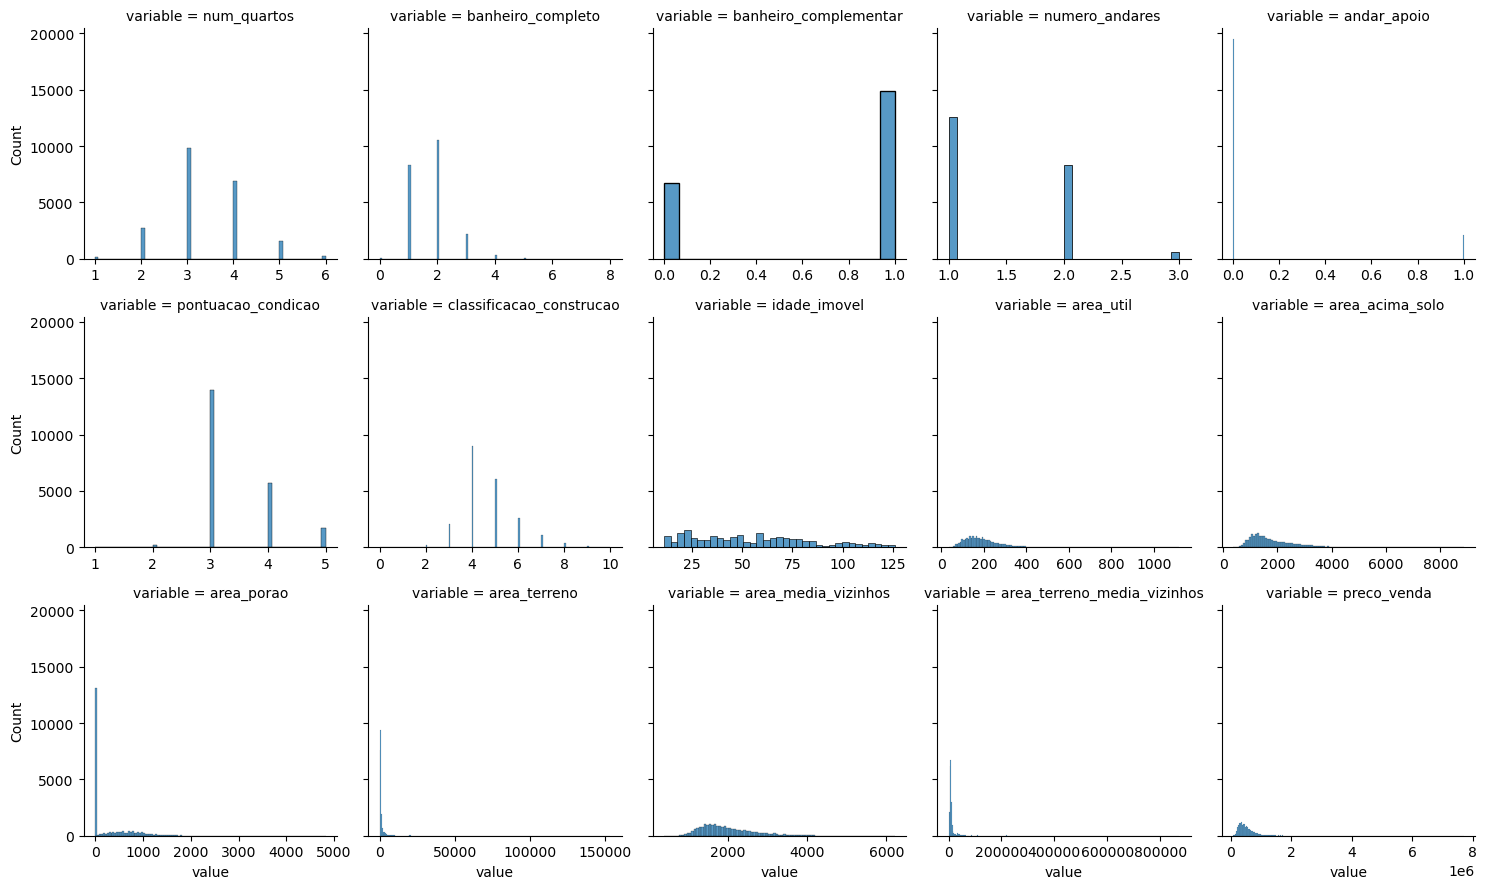

In [ ]:
# Transforma o DataFrame de formato wide para long, mantendo todas as colunas como variáveis de valor.
# Isso facilita a visualização de distribuições de múltiplas variáveis numéricas com gráficos.
hist = pd.melt(dataset_analise, value_vars=dataset_analise)

# Cria uma grade de gráficos com seaborn, separando cada variável derretida ('variable') em uma subplot.
# col_wrap=5 define no máximo 5 colunas por linha, e sharex=False garante eixos X independentes.
hist = sns.FacetGrid(hist, col='variable', col_wrap=5, sharex=False)

# Mapeia a função 'sns.histplot' para cada Faceta da grade.
# Plota um histograma para a coluna 'value' em cada subplot.
hist.map(sns.histplot, 'value')

---

A análise visual das distribuições, não me permitiu identificar conclusões profundas sobre o comportamento do mercado ou das variáveis.

Os histogramas ajudaram principalmente na compreensão inicial da estrutura dos dados, permitindo observar:

* concentração maior em faixas intermediárias;
* presença de alguns valores extremos;
* e diferenças básicas entre variáveis discretas e contínuas.

Entretanto, apenas a análise visual não é suficiente para confirmar padrões estatísticos, relações entre variáveis ou impactos reais na modelagem.

Nesse estágio, os gráficos funcionam mais como uma etapa exploratória inicial, auxiliando na familiarização com o dataset e levantando possíveis hipóteses para análises futuras mais robustas.


---

# 3.4 Matriz de Correlação e Relações Lineares

In [74]:
dataset_analise.corr()

,num_quartos,banheiro_completo,banheiro_complementar,numero_andares,andar_apoio,pontuacao_condicao,classificacao_construcao,idade_imovel,area_util,area_acima_solo,area_porao,area_terreno,area_media_vizinhos,area_terreno_media_vizinhos,preco_venda
num_quartos,1.000000,0.471041,0.253297,0.163568,0.059213,0.024420,0.374289,-0.173930,0.593489,0.494040,0.302768,0.034784,0.414363,0.033451,0.313660
banheiro_completo,0.471041,1.000000,0.148153,0.488361,-0.081651,-0.127209,0.609903,-0.441445,0.695451,0.638244,0.243766,0.084578,0.513442,0.080644,0.509729
banheiro_complementar,0.253297,0.148153,1.000000,0.332301,-0.133146,-0.071379,0.364217,-0.391282,0.347631,0.321153,0.117886,0.022151,0.316531,0.032112,0.174039
numero_andares,0.163568,0.488361,0.332301,1.000000,-0.214621,-0.294205,0.473106,-0.580929,0.353028,0.518381,-0.240027,-0.009442,0.296044,-0.013696,0.235728
andar_apoio,0.059213,-0.081651,-0.133146,-0.214621,1.000000,0.130451,-0.092963,0.373385,-0.029675,-0.023169,-0.018008,0.014856,-0.086185,0.008761,0.049706
pontuacao_condicao,0.024420,-0.127209,-0.071379,-0.294205,0.130451,1.000000,-0.147570,0.361624,-0.060307,-0.160544,0.175719,-0.008665,-0.093990,-0.003062,0.034714
classificacao_construcao,0.374289,0.609903,0.364217,0.473106,-0.092963,-0.147570,1.000000,-0.449880,0.765014,0.756877,0.165614,0.113522,0.713123,0.119601,0.667328
idade_imovel,-0.173930,-0.441445,-0.391282,-0.580929,0.373385,0.361624,-0.449880,1.000000,-0.323807,-0.428755,0.132735,-0.052481,-0.327835,-0.070261,-0.056793
area_util,0.593489,0.695451,0.347631,0.353028,-0.029675,-0.060307,0.765014,-0.323807,1.000000,0.875782,0.429031,0.171492,0.759211,0.182414,0.701420
area_acima_solo,0.494040,0.638244,0.321153,0.518381,-0.023169,-0.160544,0.756877,-0.428755,0.875782,1.000000,-0.060286,0.182562,0.732989,0.193499,0.603462


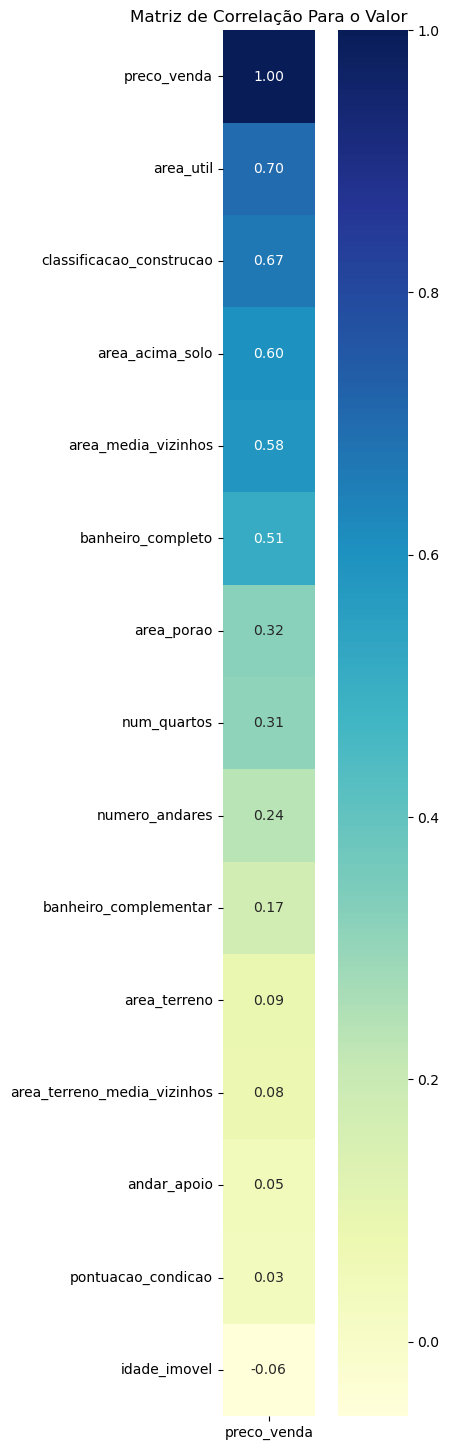

In [ ]:
# Calcula a matriz de correlação entre as variáveis numéricas
# 'drop('codigo_postal', axis=1)' remove a coluna de código postal, pois ela representa uma informação categórica/geográfica
# que não possui relação linear adequada para análise de correlação de Pearson
correlacao_dados = dataset.drop('codigo_postal', axis=1).corr()

# Seleciona apenas as correlações relacionadas à variável alvo 'preco_venda'
# '.loc['preco_venda']' retorna uma série contendo a correlação entre o preço de venda e todas as demais variáveis
correlacao_preco_venda = correlacao_dados.loc['preco_venda']

# Cria uma nova figura com tamanho personalizado
# figsize=(6,18) aumenta a altura do gráfico para facilitar a visualização das variáveis
plt.figure(figsize=(6, 18))

# Cria o heatmap de correlação
sns.heatmap(
    
    # Converte os valores de correlação em DataFrame e ordena da maior para a menor correlação
    pd.DataFrame(correlacao_preco_venda.sort_values(ascending=False)),
    # Exibe os valores numéricos dentro das células
    annot=True,    
    # Define o mapa de cores do gráfico
    cmap='YlGnBu',    
    # Exibe a barra lateral de intensidade das cores
    cbar=True,    
    # Mantém as células quadradas
    square=True,    
    # Formata os valores exibidos com duas casas decimais
    fmt='.2f'
)
# Define o título do gráfico
plt.title('Matriz de Correlação Para o Valor')
# Exibe o gráfico
plt.show()

---

A análise da matriz de correlação permitiu identificar quais variáveis possuem maior associação linear com `preco_venda`, além de indicar possíveis relações importantes entre as features do dataset.

As variáveis com maior correlação com o preço foram:

* `area_util` → 0.70
* `classificacao_construcao` → 0.67
* `area_acima_solo` → 0.60
* `area_media_vizinhos` → 0.58
* `banheiro_completo` → 0.51

Esses resultados sugerem que o valor dos imóveis está mais relacionado a:

* tamanho da área construída;
* qualidade construtiva;
* padrão das residências vizinhas;
* e quantidade de banheiros.

Por outro lado, variáveis como:

* `area_terreno`
* `area_terreno_media_vizinhos`
* `pontuacao_condicao`
* `andar_apoio`

apresentaram correlação fraca com `preco_venda`, indicando menor relação linear direta com o valor do imóvel.

Outro ponto importante identificado foi a forte correlação entre variáveis estruturais, principalmente:

* `area_util` × `area_acima_solo` → 0.88
* `area_util` × `classificacao_construcao` → 0.77
* `classificacao_construcao` × `area_acima_solo` → 0.76

Isso pode indicar possível multicolinearidade em modelos lineares.

Também foi possível observar que:

* imóveis mais novos tendem a possuir:

  * mais andares,
  * maior qualidade construtiva,
  * e mais banheiros;

já que `idade_imovel` apresentou correlação negativa com diversas variáveis estruturais.

De forma geral, a matriz sugere que o preço dos imóveis em King County parece ser mais influenciado por características estruturais e qualidade da construção do que pelo tamanho do terreno isoladamente.



---

# 4.0 Modelagem Preditiva

# 5.0 Validacao e Metricas

# 6.0 Interpretabilidade

# 7.0 Geracao de Insights